# Comparing all of the methods we used in order to evaluate the QDs

In [3]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.ndimage import median_filter
from skimage import exposure

from scipy.ndimage import binary_fill_holes, gaussian_filter
from skimage.feature import peak_local_max
from skimage.measure import label
from skimage.morphology import white_tophat, disk
from scipy.ndimage import gaussian_filter, median_filter

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "Image-Preprocessing").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT: raise FileNotFoundError("Could not find project root containing Image-Preprocessing")
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "Image-Preprocessing"))

import basic_data_preprocessing as bdp
import foreground_preprocessing as fp
import detection_algorithms as da
import detection_errors as de

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/polinabobrova/Desktop/GaN Quantum Dot Analysis


In [2]:
%%capture
%run "./npy-data-QD-DETECTION.ipynb"

ModuleNotFoundError: No module named 'nbformat'

Comparing dot detection within all of the methods

# Preprocessing and uploading the data

**1. Ground truth outputs across the 3 AFM images**

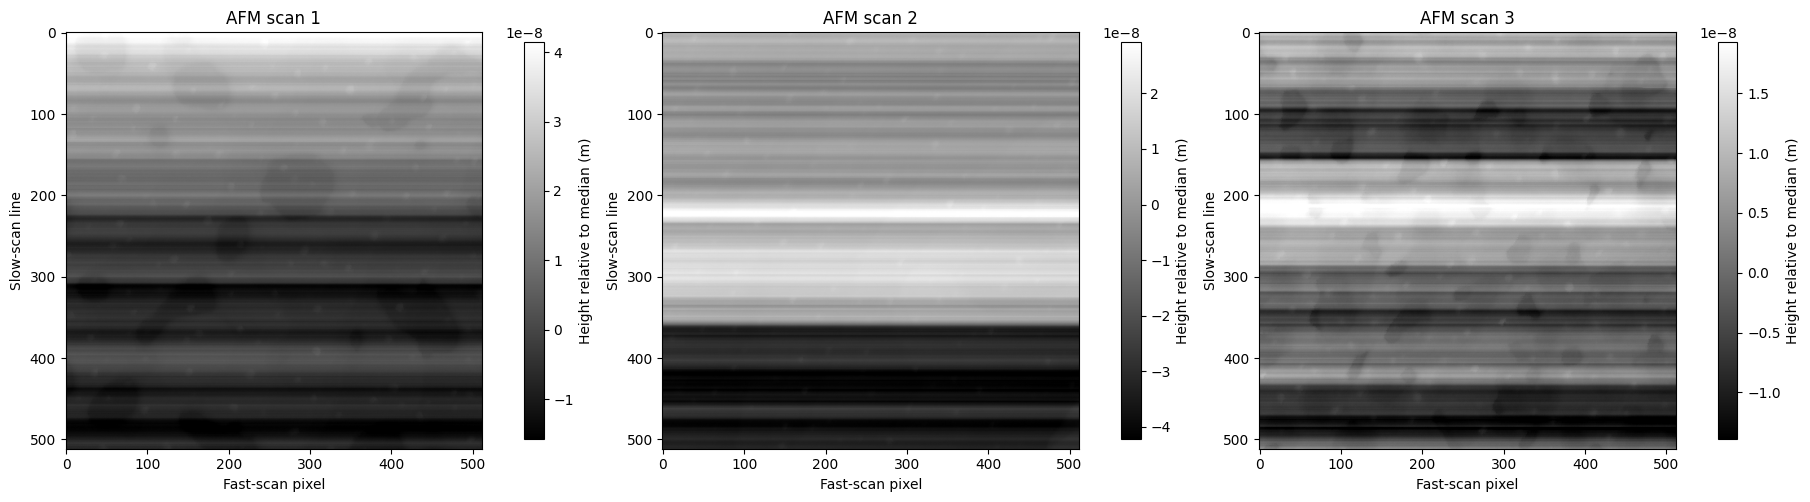

In [3]:
afm_files = [
    Path("Ground-Truth/NPY-Ground-Truth/Scan1/channel_00___0_data.npy"),
    Path("Ground-Truth/NPY-Ground-Truth/Scan2/channel_00___0_data.npy"),
    Path("Ground-Truth/NPY-Ground-Truth/Scan3/channel_00___0_data.npy"),
]

titles = [ "AFM scan 1", "AFM scan 2", "AFM scan 3",]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True,)

for ax, path, title in zip(axes, afm_files, titles):
    z = np.load(path)
    z = np.asarray(z, dtype=float)

    # Centre the height data around zero.
    z_display = z - np.nanmedian(z)

    # Robust display contrast.
    vmin, vmax = np.nanpercentile(z_display, [1, 99],)

    image = ax.imshow(z_display, cmap="gray", vmin=vmin, vmax=vmax, origin="upper",)

    ax.set_title(title)
    ax.set_xlabel("Fast-scan pixel")
    ax.set_ylabel("Slow-scan line")

    fig.colorbar(image, ax=ax, label="Height relative to median (m)", shrink=0.85,)

plt.show()

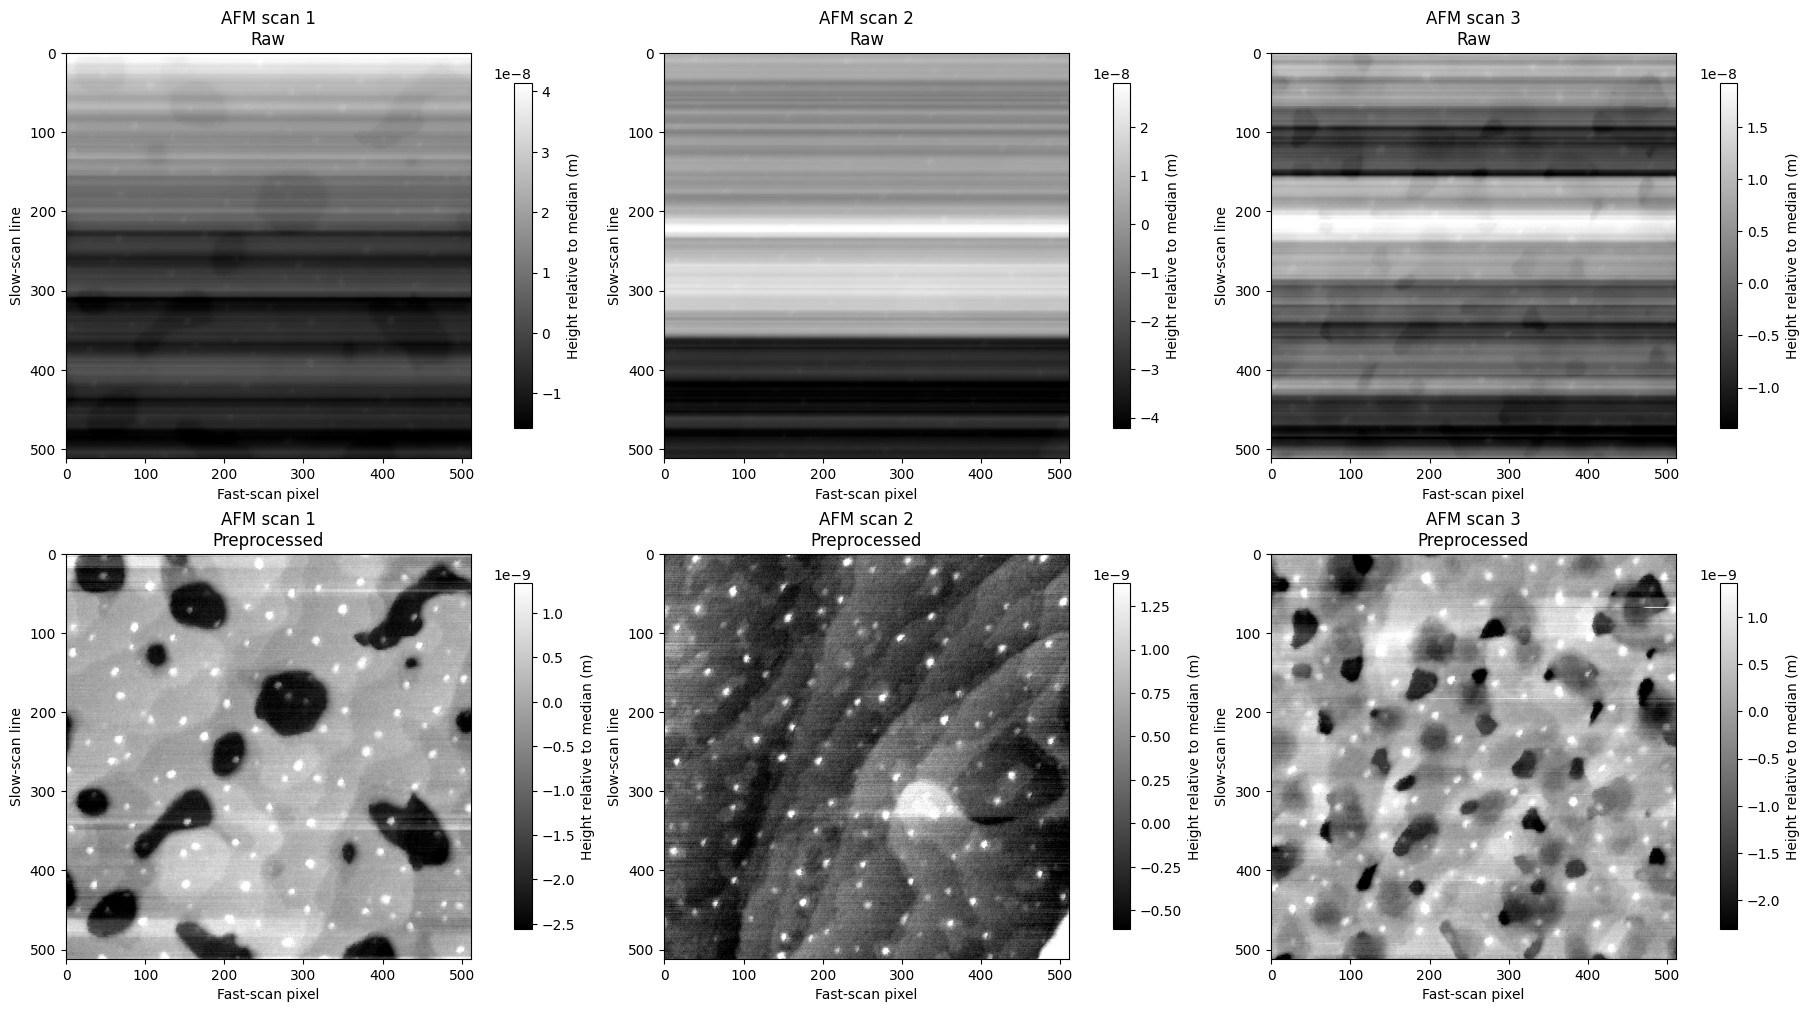

In [4]:
raw_scans = []
processed_scans = []

for path in afm_files:
    z = np.load(path)
    z = np.asarray(z, dtype=float)

    z_processed, stages = bdp.preprocess_afm(
        z,
        remove_plane=True,
        line_flatten=True,
        align_rows=True,
        remove_2d_background=False,
    )

    raw_scans.append(z)
    processed_scans.append(z_processed)


fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

for column, (raw, processed, title) in enumerate(
    zip(raw_scans, processed_scans, titles)):
    
    raw_display = raw - np.nanmedian(raw)
    raw_vmin, raw_vmax = np.nanpercentile(raw_display, [1, 99],)

    raw_image = axes[0, column].imshow(
        raw_display,
        cmap="gray",
        vmin=raw_vmin,
        vmax=raw_vmax,
        origin="upper",
    )

    axes[0, column].set_title(f"{title}\nRaw")
    axes[0, column].set_xlabel("Fast-scan pixel")
    axes[0, column].set_ylabel("Slow-scan line")

    fig.colorbar(
        raw_image,
        ax=axes[0, column],
        label="Height relative to median (m)",
        shrink=0.85,
    )

    processed_vmin, processed_vmax = np.nanpercentile(processed, [1, 99],)

    processed_image = axes[1, column].imshow(
        processed,
        cmap="gray",
        vmin=processed_vmin,
        vmax=processed_vmax,
        origin="upper",
    )

    axes[1, column].set_title(f"{title}\nPreprocessed")
    axes[1, column].set_xlabel("Fast-scan pixel")
    axes[1, column].set_ylabel("Slow-scan line")

    fig.colorbar(
        processed_image,
        ax=axes[1, column], 
        label="Height relative to median (m)",
        shrink=0.85,
    )

plt.show()

# Ground Truth Blobs Labelled

Taken from Chenuye's Dataset

### Ground-truth scan images

<p align="center">
  <img src="Ground-Truth/Images/AIX6461_centre_500nm_200pN_18 gain.0_00000_1.spm.jpg" width="31%">
  <img src="Ground-Truth/Images/AIX6468_centre_500nm_200pN_18 gain.0_00000_1.spm.jpg" width="31%">
  <img src="Ground-Truth/Images/AIX6470_centre_500nm_200pN_18 gain.0_00000_1.spm.jpg" width="31%">
</p>

### Labelled Ground-truth set

<p align="center">
  <img src="Ground-Truth/Images/LabelledQDs.png" width="100%">
</p>

In [5]:
import pandas as pd

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

from skimage.measure import label, regionprops

1. Convert a mask into QD centres 

In [6]:
def centres_from_binary_mask(binary_mask):
    binary_mask = np.asarray(binary_mask, dtype=bool)

    labelled_mask = label(binary_mask, connectivity=2,)

    centres = [region.centroid for region in regionprops(labelled_mask)]

    if not centres:
        return np.empty((0, 2), dtype=float)

    return np.asarray(centres, dtype=float)

dataset = {}
ground_truth_masks = [
    np.load("Ground-Truth/NPY-Ground-Truth/Scan1/channel_00___0_data_mask.npy"),
    np.load("Ground-Truth/NPY-Ground-Truth/Scan2/channel_00___0_data_mask.npy"),
    np.load("Ground-Truth/NPY-Ground-Truth/Scan3/channel_00___0_data_mask.npy"),
]

for scan_name, raw, processed, mask in zip(
    ["Scan1", "Scan2", "Scan3"],
    raw_scans,
    processed_scans,
    ground_truth_masks,
):
    ground_truth_centres = centres_from_binary_mask(mask)

    dataset[scan_name] = {
        "raw": raw,
        "processed": processed,
        "ground_truth_mask": mask,
        "ground_truth_centres": ground_truth_centres,
    }

    print(
        scan_name,
        "ground-truth QDs:",
        len(ground_truth_centres),
    )

Scan1 ground-truth QDs: 133
Scan2 ground-truth QDs: 137
Scan3 ground-truth QDs: 135


## 0. Analysing the data using QD detection algorithms 

Calling their functions to check everything is outputted in the same format and works well.

**Striped, no smoothing** <br>
use_destriped=False <br>
apply_smoothing=False <br>

**Striped, anisotropic smoothing** <br>
use_destriped=False <br>
apply_smoothing=True <br>

**Destriped, no smoothing** <br>
use_destriped=True <br>
apply_smoothing=False <br>

**Destriped, anisotropic smoothing** <br>
use_destriped=True <br>
apply_smoothing=True <br>

0.1 Laplacian of Gaussian

In [9]:
log_results = da.log_detect(
    z,
    z_processed,
    destriped=True,
    smoothing=True,
    gaussian_sigma=1,
    min_sigma=2,
    max_sigma=8,
    num_sigma=20,
    threshold=0.4,
    minimum_height=6e-10,
)

0.2 Chambolle anisotropic diffusion smoothing instead of Gaussian smoothing used in the above function

In [10]:
cad_results = da.chambolle_anisotropic_diffusion_detect(
    z,
    z_processed,
    destriped=True,
    smoothing=True,
    diffusion_weight=0.08,
    max_num_iter=200,
    min_sigma=2,
    max_sigma=8,
    num_sigma=20,
    threshold=0.4,
    minimum_height=6e-10,
)

0.3 QD detection via Otsu threshold being used in LoG

In [11]:
otsu_results = da.otsu_detect(
    z,
    z_processed,
    destriped=True,
    min_sigma=2,
    max_sigma=8,
    num_sigma=20,
    overlap=0.5,
    minimum_height=6e-10,
)

0.4 Hough Transform Detection 

In [12]:
ht_results = da.hough_transform_detect(
    z,
    z_processed,
    destriped=True,
    canny_sigma=1,
    min_radius=2,
    max_radius=8,
    min_xdistance=5,
    min_ydistance=5,
    threshold_relative=0.73,
    normalize=True,
    minimum_height=6e-10,
)

0.5 Perona Maulik anisotropic diffusion 

In [13]:
pmab_results = da.peronamalik_anisotropic_diffusion_detect(
    z,
    z_processed,
    destriped=True,
    smoothing=True,
    low_sigma=5,
    high_sigma=40,
    n_iterations=15,
    kappa=0.4,
    gamma=0.15,
    option=1,
    min_sigma=2,
    max_sigma=8,
    num_sigma=20,
    threshold=0.4,
    minimum_height=6e-10,
)

0.6 Phase congruency/ phase symmetry 

In [14]:
pc_results = da.detect_qds_phase_symmetry(
    z,
    z_processed,
    destriped=True,
    nscale=6,
    min_wavelength=1.5,
    mult=9.0,
    noise_k=2.5,
    symmetry_threshold=0.08,
    min_distance=3,
    minimum_height=6e-10,
)

0.7 SIFT detection 

In [15]:
sift_results = da.sift_detect(
    z,
    z_processed,
    destriped=True,
    background_sigma=10,
    qd_min_sigma=0.8,
    qd_max_sigma=4.0,
    upsampling=2,
    n_octaves=3,
    n_scales=5,
    sigma_min=2,
    sigma_in=0.5,
    c_dog=0.05,
    c_edge=15,
    lower_percentile=1,
    upper_percentile=99,
    minimum_height=6e-10,
)

0.8 Using geometric contours for QD detection 

In [16]:
da.geometric_contour_detect(
    z,
    z_processed,
    striped_centres=log_centres,
    destriped_centres=log_centres,
    destriped=True,
    minimum_height=6e-10,
)

NameError: name 'log_centres' is not defined

0.9 Using Chan-Vese contur detection 

In [17]:
da.chan_vese_detect(
    z,
    z_processed,
    300, # striped centres 
    250, # destriped centres 
    destriped=True,
    initial_radius=3,
    num_iter=80,
    smoothing=1,
    lambda1=1,
    lambda2=2,
    min_area=1,
    minimum_height=6e-10,
)

ValueError: cannot reshape array of size 1 into shape (2)

0.10 Watershed detection 

In [18]:
ws_results = da.watershed_detect(
    z,
    z_processed,
    destriped=True,
    footprint_radius=6,
    min_size=1,
    min_distance=3,
    min_area=5,
    minimum_height=6e-10,
)

0.11 Using Gabor wavelets for QD detection -> this takes longest to execute by time 

In [19]:
gw_results = da.gabor_detect(
    z,
    z_processed,
    destriped=True,
    smoothing_sigma=0.58,
    top_hat_radius=6,
    wavelengths=(2, 3, 4, 5, 6, 8),
    number_of_orientations=8,
    bandwidth=1.0,
    threshold_percentile=90,
    min_distance=2,
    minimum_height=6e-10,
)

## 2. Object-level detection metrics 

This will help identifying if the algorithms managed to find the correct dots - this compares predicted and real centres 

In [20]:
algorithm_results = {
    "LoG": log_results,
    "CAD": cad_results,
    "Otsu": otsu_results,
    "HT": ht_results,
    "PMAD": pmab_results,
    "PC": pc_results,
    "SIFT": sift_results,
    "WS": ws_results,
    "GW": gw_results,
}

## 3. Error table

In [21]:
rows = []

true_centres = dataset["Scan3"]["ground_truth_centres"]

true_result = {
    "mask": dataset["Scan3"]["ground_truth_mask"],
    "centres": true_centres,
    "heights": np.full(len(true_centres), np.nan),
    "radii": np.full(len(true_centres), np.nan),
    "areas": np.full(len(true_centres), np.nan),
}


for algorithm_name, result in algorithm_results.items():
    rows.append(
        da.make_results_row(
            algorithm_name=algorithm_name,
            stage_name="Before height filter",
            predicted_result=result["before_height_filter"],
            true_result=true_result,
        )
    )

    rows.append(
        da.make_results_row(
            algorithm_name=algorithm_name,
            stage_name="After height filter",
            predicted_result=result["after_height_filter"],
            true_result=true_result,
        )
    )

results_table = pd.DataFrame(rows)
results_table = results_table.round(4)

display(results_table)

,Algorithm,Stage,Predicted count,True count,Count error,Absolute count error,Pixel precision,Pixel recall,Pixel F1,Dice,...,Localisation mean (px),Localisation median (px),Localisation RMSE (px),Localisation maximum (px),Height MAE,Height RMSE,Radius MAE,Radius RMSE,Area MAE,Area RMSE
0,LoG,Before height filter,232,135,97,97,0.2037,0.7590,0.3212,0.3212,...,1.8139,1.5660,2.1762,5.0000,NaN,NaN,NaN,NaN,NaN,NaN
1,LoG,After height filter,138,135,3,3,0.3761,0.6897,0.4867,0.4867,...,1.6893,1.4250,2.0341,5.0000,NaN,NaN,NaN,NaN,NaN,NaN
2,CAD,Before height filter,253,135,118,118,0.1990,0.7435,0.3139,0.3139,...,1.8254,1.5834,2.1839,5.0000,NaN,NaN,NaN,NaN,NaN,NaN
3,CAD,After height filter,141,135,6,6,0.3803,0.6711,0.4855,0.4855,...,1.6938,1.4120,2.0403,5.0000,NaN,NaN,NaN,NaN,NaN,NaN
4,Otsu,Before height filter,322,135,187,187,0.1737,0.7528,0.2823,0.2823,...,1.8057,1.5660,2.1647,5.0000,NaN,NaN,NaN,NaN,NaN,NaN
5,Otsu,After height filter,154,135,19,19,0.3707,0.6722,0.4779,0.4779,...,1.7138,1.4250,2.0468,5.0000,NaN,NaN,NaN,NaN,NaN,NaN
6,HT,Before height filter,491,135,356,356,0.1317,0.0711,0.0924,0.0924,...,1.8747,1.8679,2.1480,4.3791,NaN,NaN,NaN,NaN,NaN,NaN
7,HT,After height filter,28,135,-107,107,0.9026,0.0662,0.1233,0.1233,...,1.7720,1.5965,2.0484,4.3791,NaN,NaN,NaN,NaN,NaN,NaN
8,PMAD,Before height filter,117,135,-18,18,0.1466,0.5985,0.2355,0.2355,...,1.8272,1.7096,2.0613,4.3904,NaN,NaN,NaN,NaN,NaN,NaN
9,PMAD,After height filter,73,135,-62,62,0.2025,0.5253,0.2923,0.2923,...,1.8568,1.7096,2.0847,4.3904,NaN,NaN,NaN,NaN,NaN,NaN


**Then, I decided to overlay the binary masks:**

1. ground truth = green transparent
2. prediction = magenta transparent

In [22]:
import math

def plot_detection_overlays_filled(
    algorithm_results,
    true_result,
    base_image,
    stage_key="after_height_filter",
    cmap="grey",
):
    algorithm_names = list(algorithm_results.keys())
    n_methods = len(algorithm_names)

    ncols = 3
    nrows = math.ceil(n_methods / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 5 * nrows),
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).ravel()

    base_image = np.asarray(base_image, dtype=float)
    true_mask = np.asarray(true_result["mask"], dtype=bool)

    for ax, algorithm_name in zip(axes, algorithm_names):
        result = algorithm_results[algorithm_name]
        predicted = result[stage_key]
        predicted_mask = np.asarray(predicted["mask"], dtype=bool)

        ax.imshow(base_image, cmap=cmap, origin="upper")

        # Ground truth overlay: green
        true_overlay = np.zeros((*true_mask.shape, 4), dtype=float)
        true_overlay[..., 1] = 1.0
        true_overlay[..., 3] = 0.28 * true_mask
        ax.imshow(true_overlay, origin="upper")

        # Predicted overlay: magenta
        pred_overlay = np.zeros((*predicted_mask.shape, 4), dtype=float)
        pred_overlay[..., 0] = 1.0
        pred_overlay[..., 2] = 1.0
        pred_overlay[..., 3] = 0.28 * predicted_mask
        ax.imshow(pred_overlay, origin="upper")

        ax.set_title(
            f"{algorithm_name}\n"
            f"GT: {len(true_result['centres'])} | Pred: {len(predicted['centres'])}"
        )
        ax.set_xlabel("x pixel")
        ax.set_ylabel("y pixel")

    for ax in axes[n_methods:]:
        ax.axis("off")

    fig.suptitle(
        f"Filled detection overlays — {stage_key.replace('_', ' ').title()}\n"
        f"Green = Ground truth, Magenta = Prediction",
        fontsize=14,
    )

    plt.show()

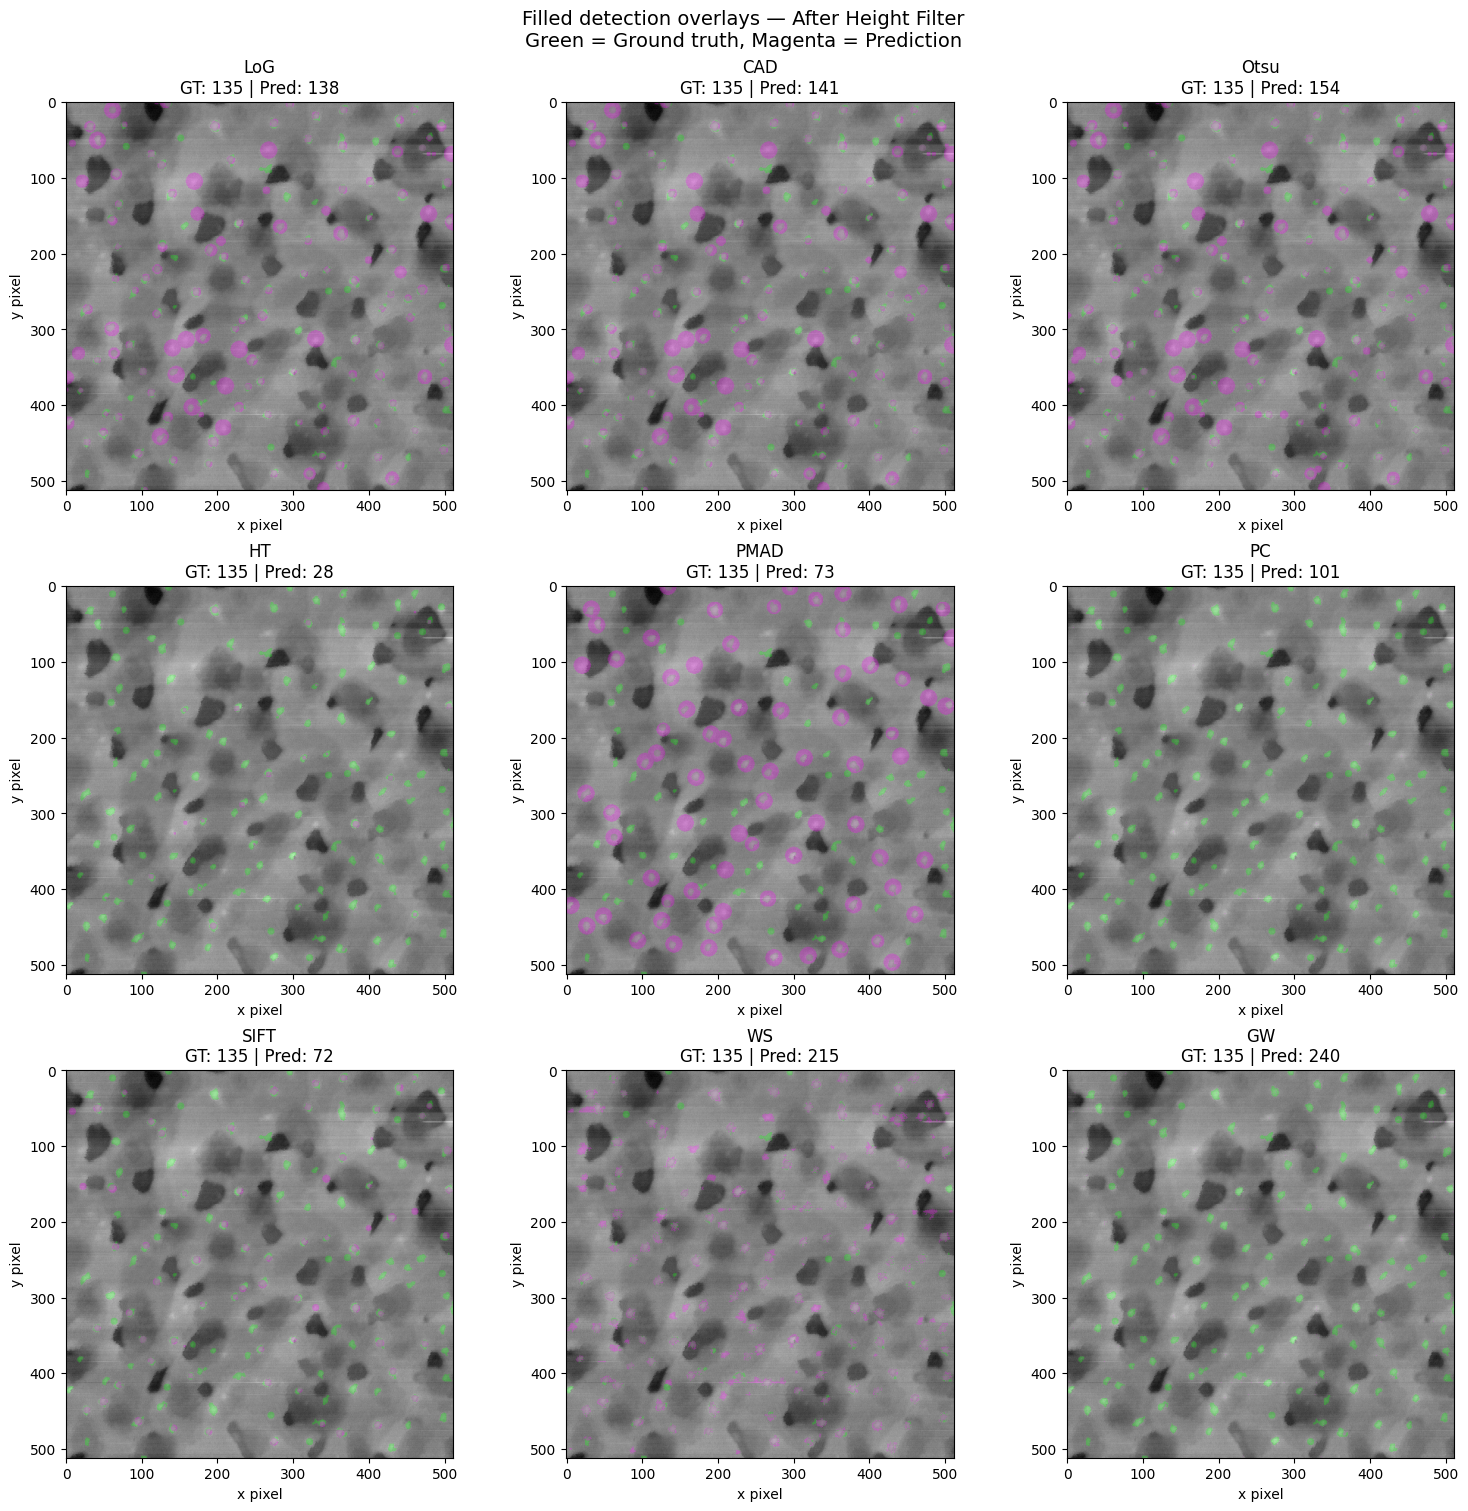

In [23]:
plot_detection_overlays_filled(
    algorithm_results=algorithm_results,
    true_result=true_result,
    base_image=dataset["Scan3"]["processed"],
    stage_key="after_height_filter",
)

In [24]:
def finite_values(values):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values)]


def plot_parameter_histograms(
    algorithm_results,
    true_result,
    stage_key="after_height_filter",
    parameter_key="radii",
    parameter_label="Radius (px)",
    bins=20,
):
    algorithm_names = list(algorithm_results.keys())
    n_methods = len(algorithm_names)

    ncols = 3
    nrows = math.ceil(n_methods / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 4 * nrows),
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).ravel()

    true_values = finite_values(true_result[parameter_key])

    for ax, algorithm_name in zip(axes, algorithm_names):
        predicted_result = algorithm_results[algorithm_name][stage_key]
        predicted_values = finite_values(predicted_result[parameter_key])

        if len(true_values) > 0:
            ax.hist(
                true_values,
                bins=bins,
                alpha=0.5,
                density=False,
                label="Ground truth",
            )

        if len(predicted_values) > 0:
            ax.hist(
                predicted_values,
                bins=bins,
                alpha=0.5,
                density=False,
                label=algorithm_name,
            )

        ax.set_title(f"{algorithm_name} — {stage_key.replace('_', ' ')}")
        ax.set_xlabel(parameter_label)
        ax.set_ylabel("Frequency")
        ax.legend()

    for ax in axes[n_methods:]:
        ax.axis("off")

    plt.show()

radius errors

/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_90244/2704427778.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


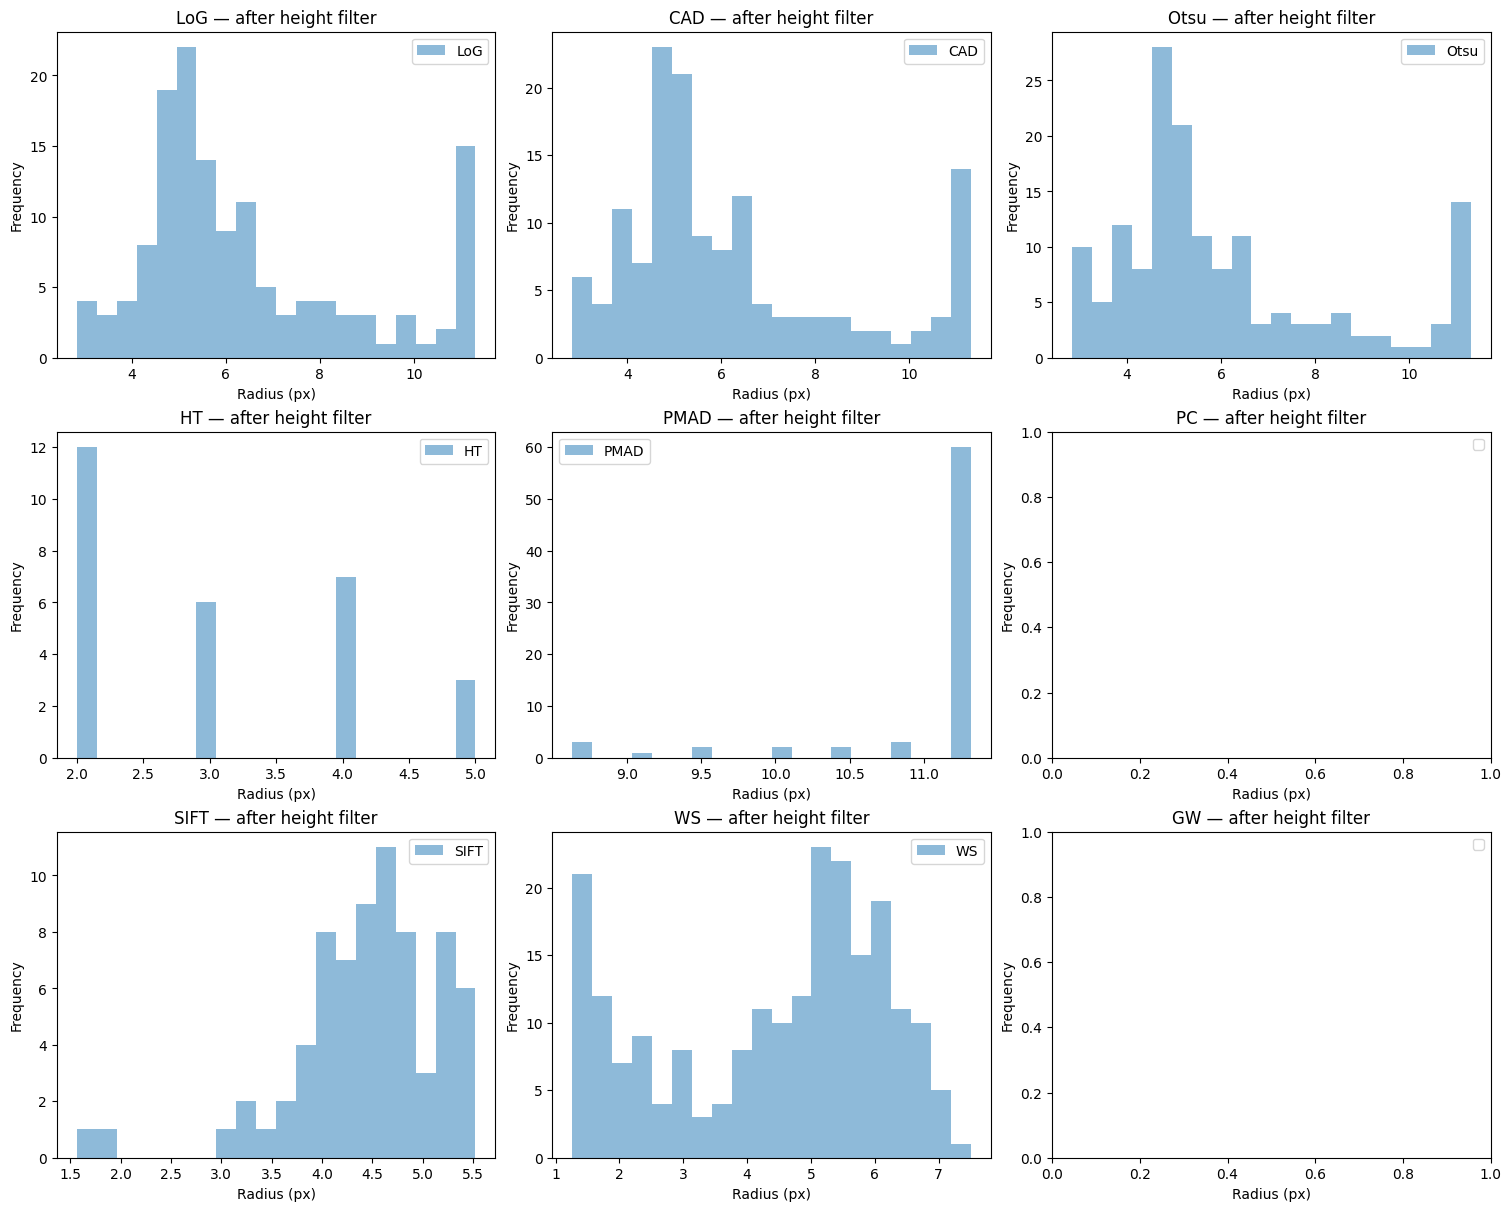

In [25]:
plot_parameter_histograms(
    algorithm_results=algorithm_results,
    true_result=true_result,
    stage_key="after_height_filter",
    parameter_key="radii",
    parameter_label="Radius (px)",
    bins=20,
)

area errors

/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_90244/2704427778.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


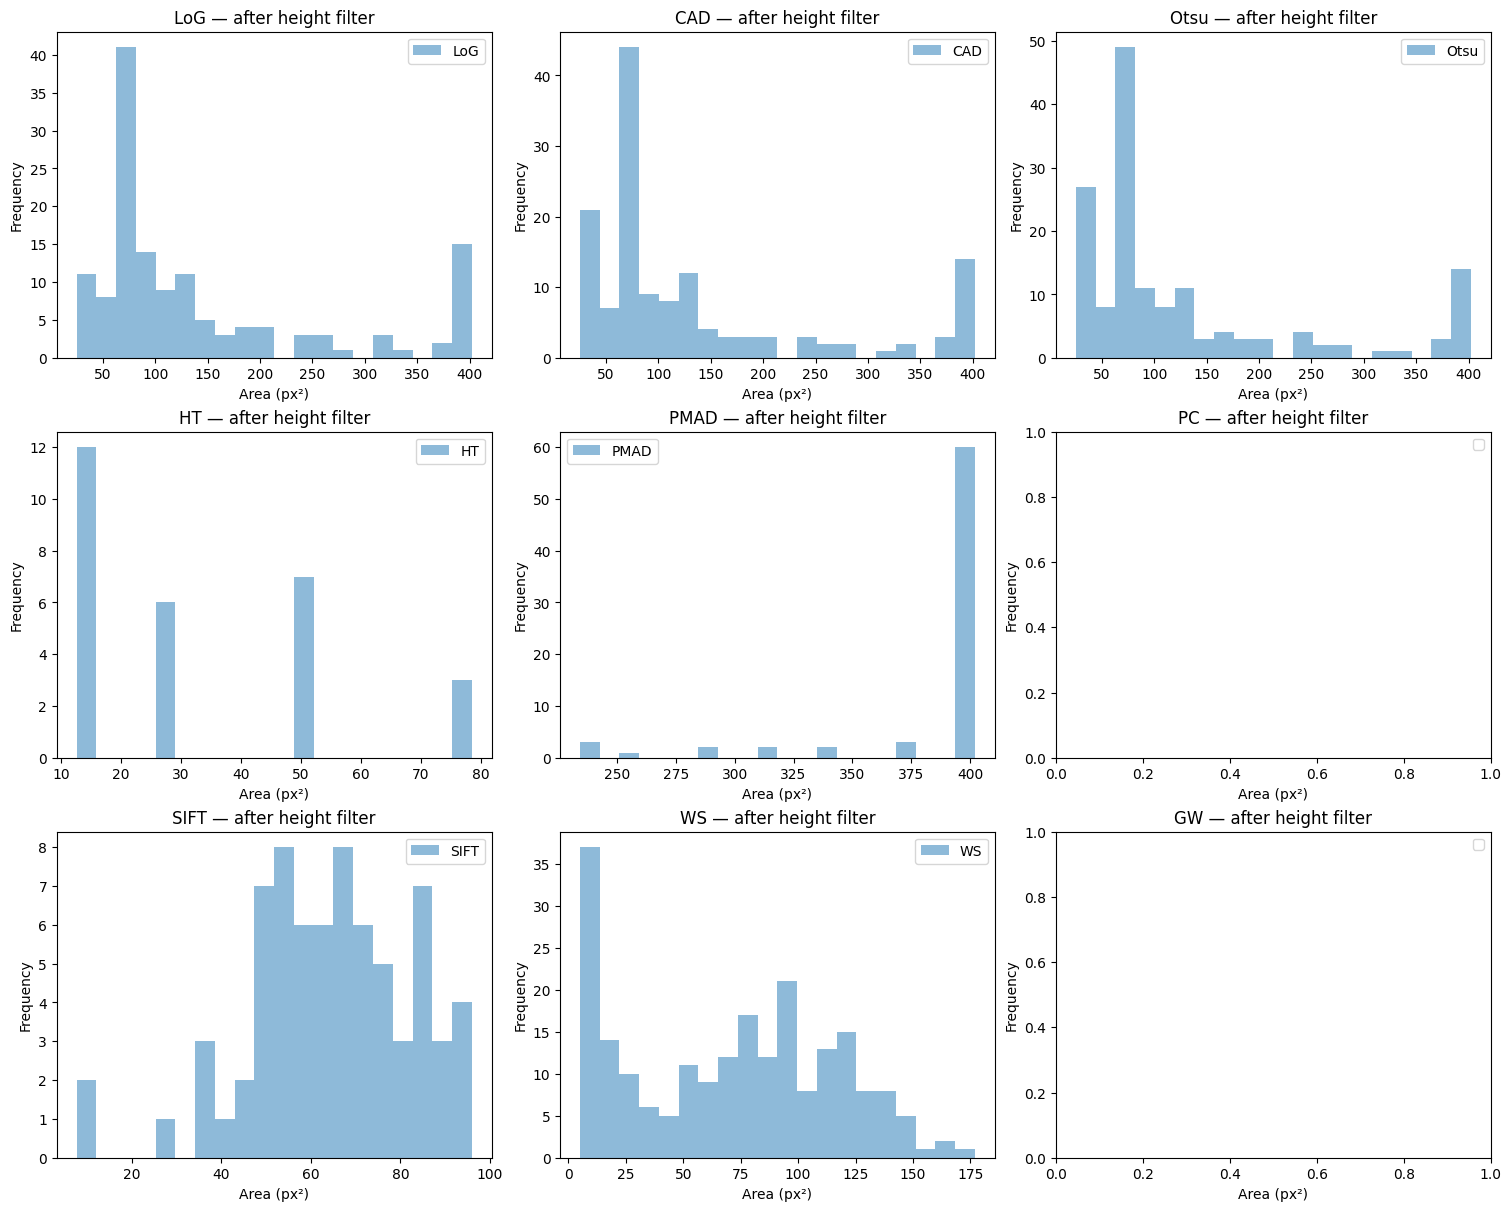

In [26]:
plot_parameter_histograms(
    algorithm_results=algorithm_results,
    true_result=true_result,
    stage_key="after_height_filter",
    parameter_key="areas",
    parameter_label="Area (px²)",
    bins=20,
)

heights

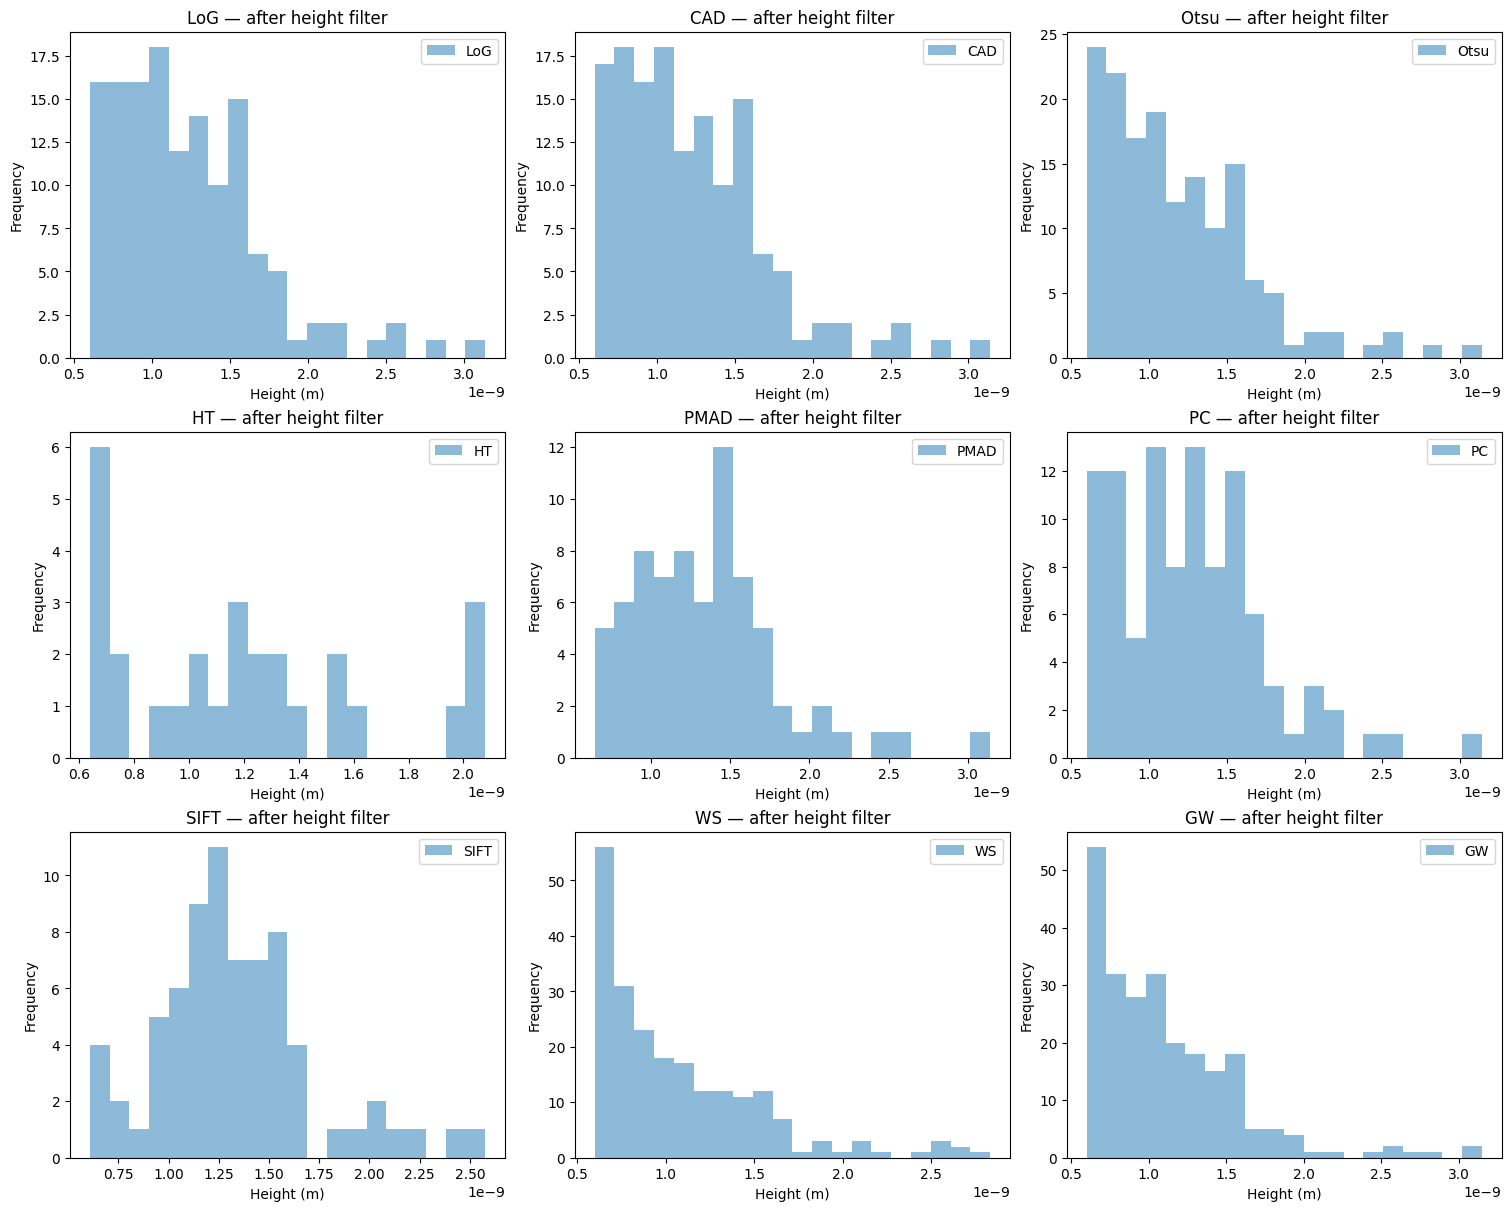

In [27]:
plot_parameter_histograms(
    algorithm_results=algorithm_results,
    true_result=true_result,
    stage_key="after_height_filter",
    parameter_key="heights",
    parameter_label="Height (m)",
    bins=20,
)

Histogram of matched errors:

In [28]:
from skimage.measure import label, regionprops
import numpy as np


def ground_truth_parameters_from_mask(binary_mask):
    labelled_mask = label(
        np.asarray(binary_mask, dtype=bool),
        connectivity=2,
    )

    regions = regionprops(labelled_mask)

    centres = np.asarray(
        [region.centroid for region in regions],
        dtype=float,
    ).reshape(-1, 2)

    areas = np.asarray(
        [region.area for region in regions],
        dtype=float,
    )

    radii = np.sqrt(areas / np.pi)

    return centres, radii, areas

In [29]:
gt_centres, gt_radii, gt_areas = ground_truth_parameters_from_mask(
    dataset["Scan3"]["ground_truth_mask"]
)

In [30]:
true_result = {
    "mask": dataset["Scan3"]["ground_truth_mask"],
    "centres": gt_centres,
    "heights": np.full(len(gt_centres), np.nan),
    "radii": gt_radii,
    "areas": gt_areas,
}

In [32]:
import math
import numpy as np
import matplotlib.pyplot as plt


def plot_parameter_error_histograms(
    algorithm_results,
    true_result,
    stage_key="after_height_filter",
    parameter_key="radii",
    parameter_label="Radius error (px)",
    bins=20,
    max_distance=5,
):
    algorithm_names = list(algorithm_results.keys())
    n_methods = len(algorithm_names)

    ncols = 3
    nrows = math.ceil(n_methods / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 4 * nrows),
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, algorithm_name in zip(axes, algorithm_names):
        predicted_result = algorithm_results[algorithm_name][stage_key]

        matches = de.match_qds(
            predicted_result["centres"],
            true_result["centres"],
            max_distance=max_distance,
        )

        predicted_indices = matches["predicted_indices"]
        true_indices = matches["true_indices"]

        predicted_values = np.asarray(predicted_result[parameter_key], dtype=float)
        true_values = np.asarray(true_result[parameter_key], dtype=float)

        errors = predicted_values[predicted_indices] - true_values[true_indices]
        errors = errors[np.isfinite(errors)]

        if len(errors) > 0:
            ax.hist(
                errors,
                bins=bins,
                alpha=0.7,
            )
            ax.axvline(0, linestyle="--")
            ax.set_title(
                f"{algorithm_name}\n"
                f"mean error = {np.mean(errors):.4g}, n = {len(errors)}"
            )
        else:
            ax.set_title(f"{algorithm_name}\nNo valid matched errors")

        ax.set_xlabel(parameter_label)
        ax.set_ylabel("Frequency")

    for ax in axes[n_methods:]:
        ax.axis("off")

    plt.show()

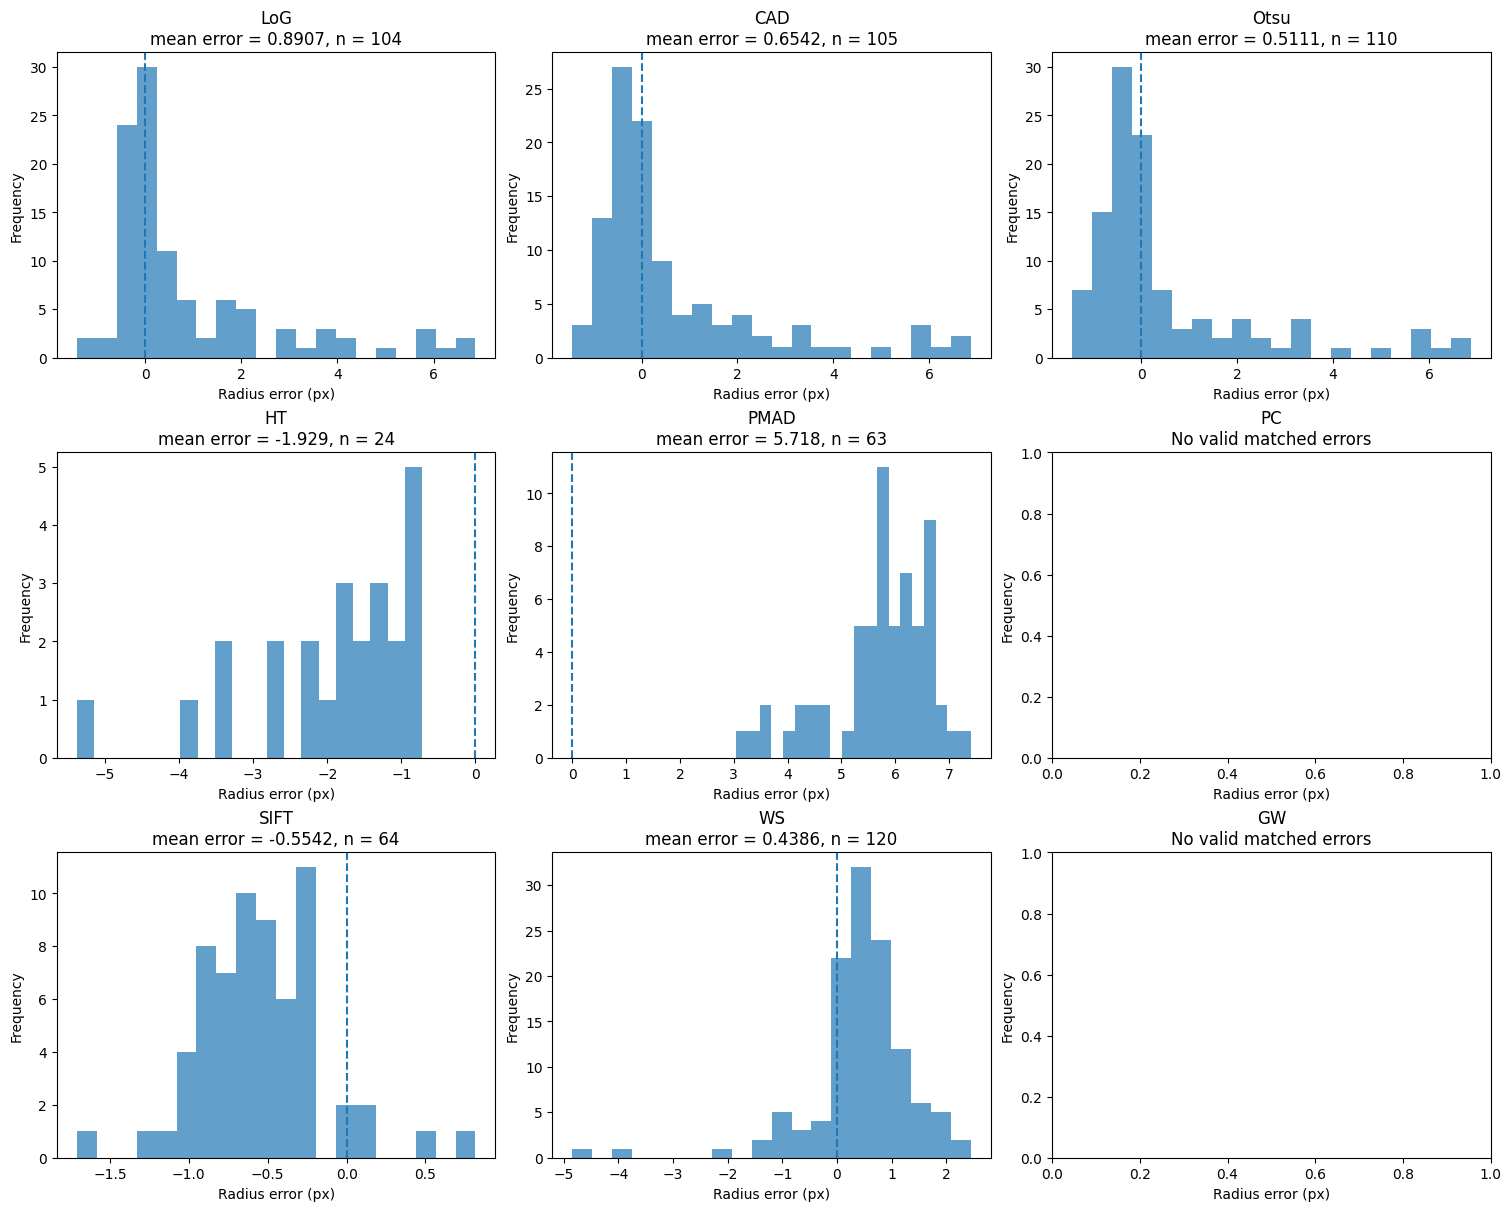

In [33]:
plot_parameter_error_histograms(
    algorithm_results=algorithm_results,
    true_result=true_result,
    stage_key="after_height_filter",
    parameter_key="radii",
    parameter_label="Radius error (px)",
    bins=20,
    max_distance=5,
)

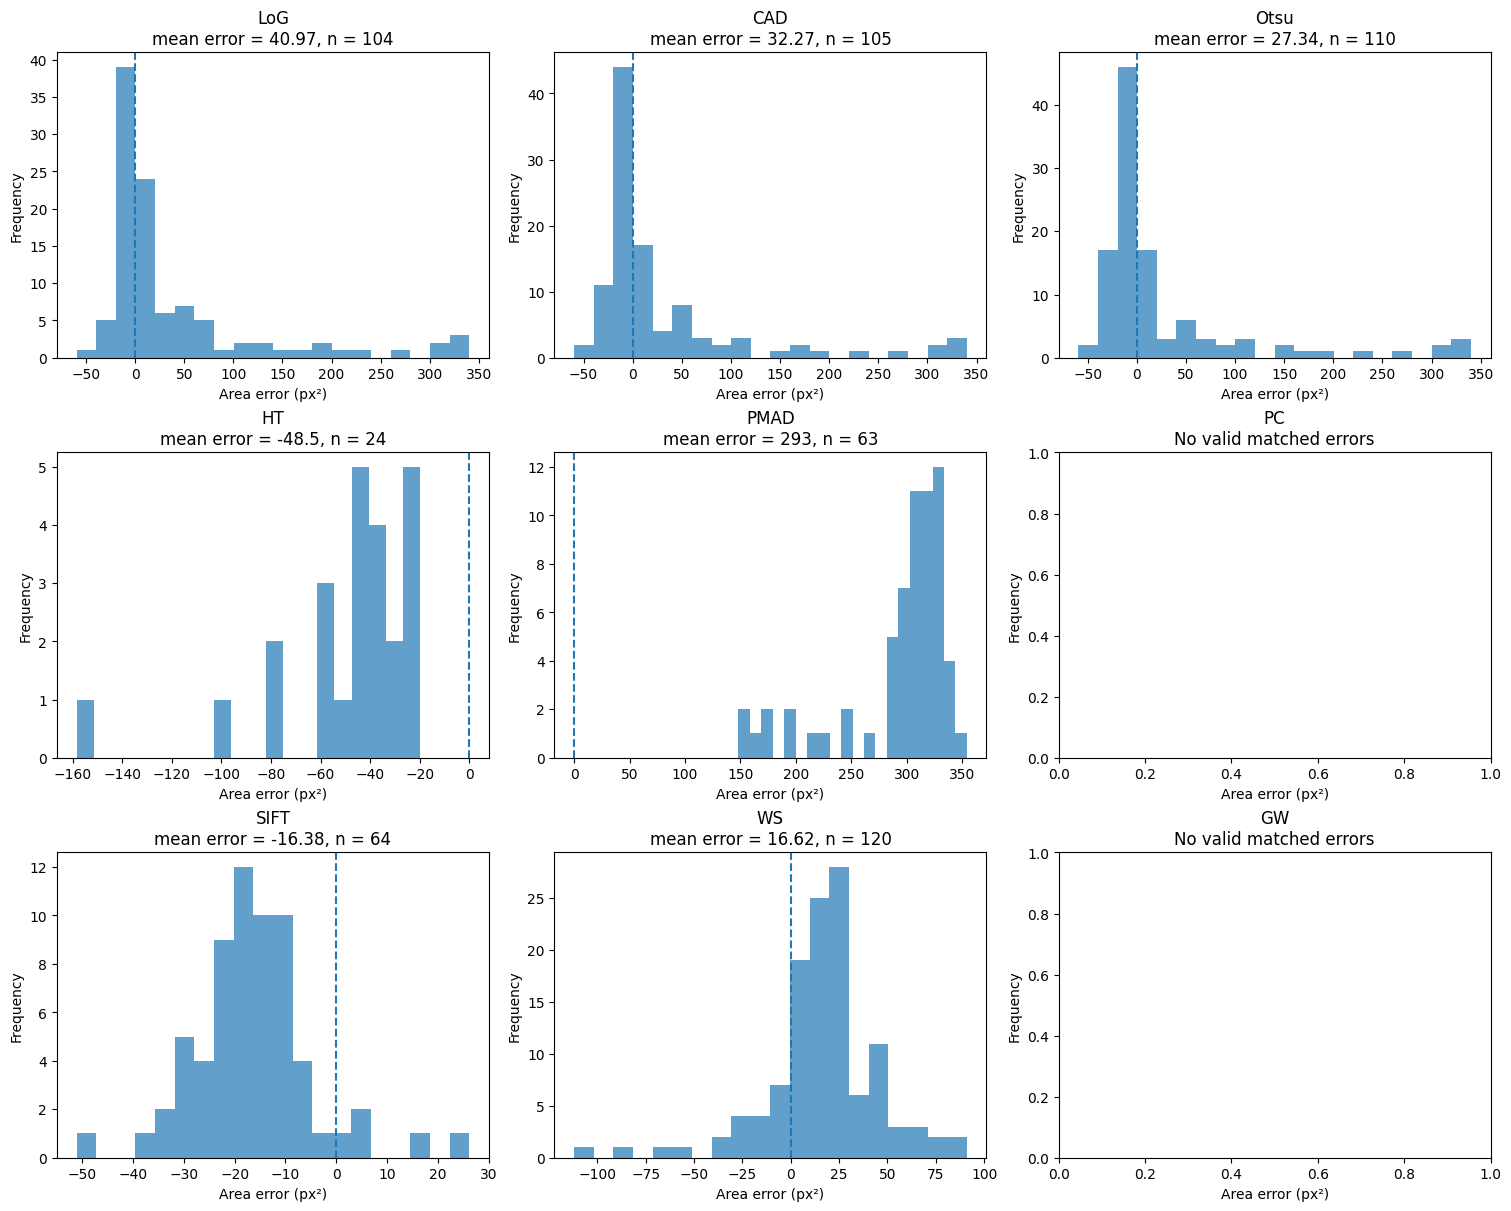

In [34]:
plot_parameter_error_histograms(
    algorithm_results=algorithm_results,
    true_result=true_result,
    stage_key="after_height_filter",
    parameter_key="areas",
    parameter_label="Area error (px²)",
    bins=20,
    max_distance=5,
)

height error

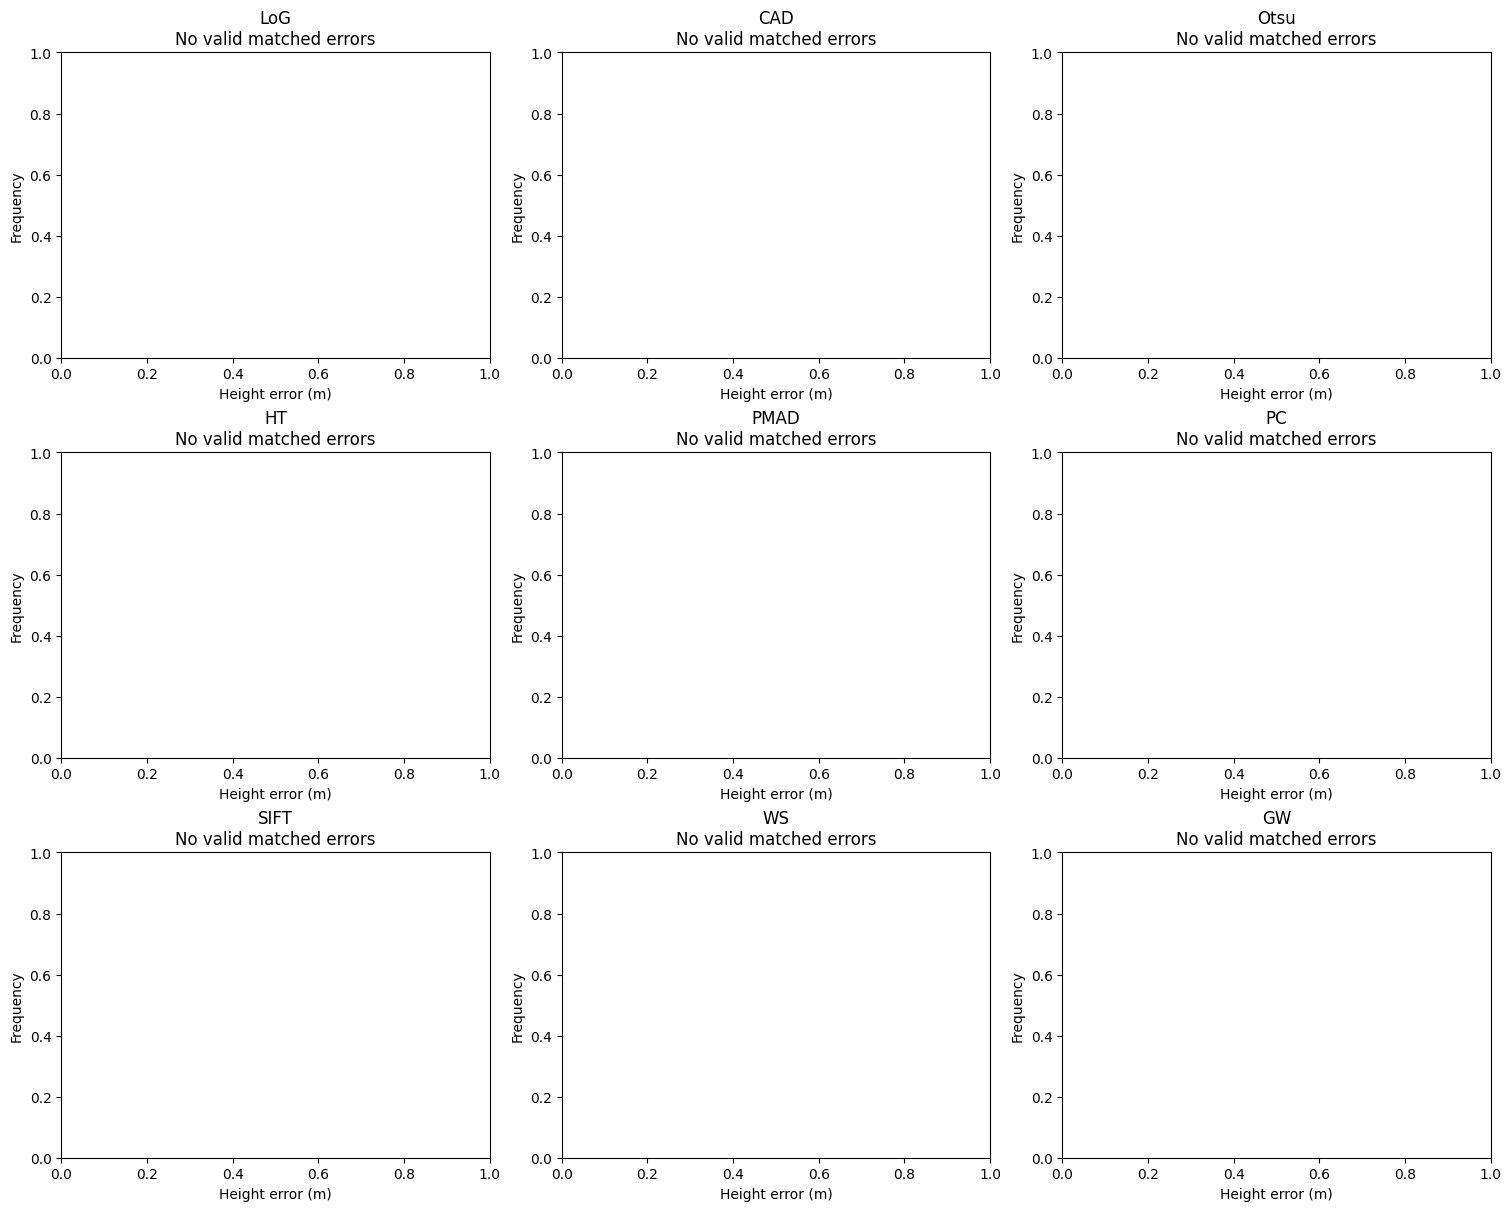

In [35]:
plot_parameter_error_histograms(
    algorithm_results=algorithm_results,
    true_result=true_result,
    stage_key="after_height_filter",
    parameter_key="heights",
    parameter_label="Height error (m)",
    bins=20,
    max_distance=5,
)

# Feature-wise Evaluation


In [36]:
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "Ground-Truth").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT: raise FileNotFoundError("Could not find project root containing Ground-Truth")
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "Ground-Truth"))

import feature_evaluation as fe

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/polinabobrova/Desktop/GaN Quantum Dot Analysis


In [37]:
from IPython.display import display
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy import ndimage
from scipy.spatial import KDTree
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects
import matplotlib.pyplot as plt

In [38]:
# LOAD SCAN 3
scan_folder = PROJECT_ROOT / "Ground-Truth/NPY-Ground-Truth/Scan3"
image = np.load(scan_folder / "channel_00___0_data.npy")
Y_test = np.load(scan_folder / "channel_00___0_data_mask.npy").astype(bool)


# PREPROCESS
image_preprocessed, _ = bdp.preprocess_afm(image, remove_plane=True, line_flatten=True, align_rows=True, remove_2d_background=False)
X_test = bdp.robust_normalise(image_preprocessed)# LOAD SCAN 3
scan_folder = PROJECT_ROOT / "Ground-Truth/NPY-Ground-Truth/Scan3"
image = np.load(scan_folder / "channel_00___0_data.npy")
Y_test = np.load(scan_folder / "channel_00___0_data_mask.npy").astype(bool)


# PREPROCESS
image_preprocessed, _ = bdp.preprocess_afm(image, remove_plane=True, line_flatten=True, align_rows=True, remove_2d_background=False)
X_test = bdp.robust_normalise(image_preprocessed)

In [39]:
# RUN CLASSICAL ALGORITHMS
algorithm_results = {}
algorithm_results["LoG"] = da.log_detect(image, image_preprocessed)
algorithm_results["Chambolle"] = da.chambolle_anisotropic_diffusion_detect(image, image_preprocessed)
algorithm_results["Otsu"] = da.otsu_detect(image, image_preprocessed)
algorithm_results["Hough"] = da.hough_transform_detect(image, image_preprocessed)
algorithm_results["Perona-Malik"] = da.peronamalik_anisotropic_diffusion_detect(image, image_preprocessed)
algorithm_results["Phase symmetry"] = da.detect_qds_phase_symmetry(image, image_preprocessed)
algorithm_results["SIFT"] = da.sift_detect(image, image_preprocessed)
algorithm_results["Watershed"] = da.watershed_detect(image, image_preprocessed)
algorithm_results["Gabor"] = da.gabor_detect(image, image_preprocessed)


# CONTOUR METHODS INITIALISED FROM LOG
#log_centres = algorithm_results["LoG"]["before_height_filter"]["centres"]
#algorithm_results["LoG + MGAC"] = da.geometric_contour_detect(image, image_preprocessed, log_centres, log_centres)
#algorithm_results["LoG + Chan-Vese"] = da.chan_vese_detect(image, image_preprocessed, log_centres, log_centres)

In [40]:
# EVALUATE CLASSICAL ALGORITHMS
rows = []
for algorithm_name, result in algorithm_results.items():
    for stage in ["before_height_filter", "after_height_filter"]:
        metrics = fe.evaluate_feature_masks(Y_test, result[stage]["mask"], tolerance=3.0)
        rows.append({"Algorithm": algorithm_name, "Stage": stage, **metrics})


# LOAD U-NET
model = tf.keras.models.load_model(PROJECT_ROOT / "Ground-Truth/qd_unet_fold1.keras", compile=False)

# U-NET PREDICTION
prediction = fe.predict_full_scan(model, X_test, patch_size=128)


# EVALUATE U-NET AT YOUR CURRENT THRESHOLD
unet_threshold = 0.20
unet_mask = remove_small_objects(prediction >= unet_threshold, min_size=1)
unet_metrics = fe.evaluate_feature_masks(Y_test, unet_mask, tolerance=3.0)
rows.append({"Algorithm": "U-Net", "Stage": f"threshold={unet_threshold:.2f}", **unet_metrics})


In [41]:
# FINAL TABLE
results_df = pd.DataFrame(rows)
results_df = results_df[["Algorithm", "Stage", "GT count", "Predicted count", "TP", "FP", "FN", "Precision", "Recall", "F1"]]
print(results_df.sort_values("F1", ascending=False).to_string(index=False))

     Algorithm                Stage  GT count  Predicted count  TP   FP  FN  Precision   Recall       F1
         U-Net       threshold=0.20       138              136 117   19  21   0.860294 0.847826 0.854015
     Watershed  after_height_filter       138              185 116   69  22   0.627027 0.840580 0.718266
     Chambolle  after_height_filter       138              138  99   39  39   0.717391 0.717391 0.717391
          Otsu  after_height_filter       138              147 101   46  37   0.687075 0.731884 0.708772
           LoG  after_height_filter       138              136  97   39  41   0.713235 0.702899 0.708029
Phase symmetry  after_height_filter       138              101  74   27  64   0.732673 0.536232 0.619247
          SIFT  after_height_filter       138               72  60   12  78   0.833333 0.434783 0.571429
           LoG before_height_filter       138              211  93  118  45   0.440758 0.673913 0.532951
         Gabor  after_height_filter       138          

In [42]:
# TEST U-NET OBJECT-LEVEL F1 ACROSS THRESHOLDS
threshold_rows = []
for threshold in np.arange(0.05, 0.96, 0.05):
    mask = remove_small_objects(prediction >= threshold, min_size=1)
    metrics = fe.evaluate_feature_masks(Y_test, mask, tolerance=3.0)
    threshold_rows.append({"Threshold": threshold, **metrics})

unet_threshold_df = pd.DataFrame(threshold_rows)
print("\nU-NET THRESHOLD SWEEP:")
print(unet_threshold_df.sort_values("F1", ascending=False).to_string(index=False))

best = unet_threshold_df.loc[unet_threshold_df["F1"].idxmax()]
print("\nBest U-Net threshold on this scan:")
print(best)


U-NET THRESHOLD SWEEP:
 Threshold  TP  FP  FN  GT count  Predicted count  Precision   Recall       F1
      0.20 117  19  21       138              136   0.860294 0.847826 0.854015
      0.30 114  16  24       138              130   0.876923 0.826087 0.850746
      0.05 124  30  14       138              154   0.805195 0.898551 0.849315
      0.15 117  22  21       138              139   0.841727 0.847826 0.844765
      0.10 119  26  19       138              145   0.820690 0.862319 0.840989
      0.25 115  21  23       138              136   0.845588 0.833333 0.839416
      0.35 112  18  26       138              130   0.861538 0.811594 0.835821
      0.70 109  14  29       138              123   0.886179 0.789855 0.835249
      0.60 109  15  29       138              124   0.879032 0.789855 0.832061
      0.50 110  17  28       138              127   0.866142 0.797101 0.830189
      0.40 110  17  28       138              127   0.866142 0.797101 0.830189
      0.65 108  15  30      

In [43]:
# ADD U-NET TO THE SAME RESULTS DICTIONARY SO IT CAN BE DISPLAYED WITH EVERYTHING
unet_mask = remove_small_objects(prediction >= 0.20, min_size=1)
algorithm_results["U-Net"] = {"before_height_filter": {"mask": unet_mask}, "after_height_filter": {"mask": unet_mask}}

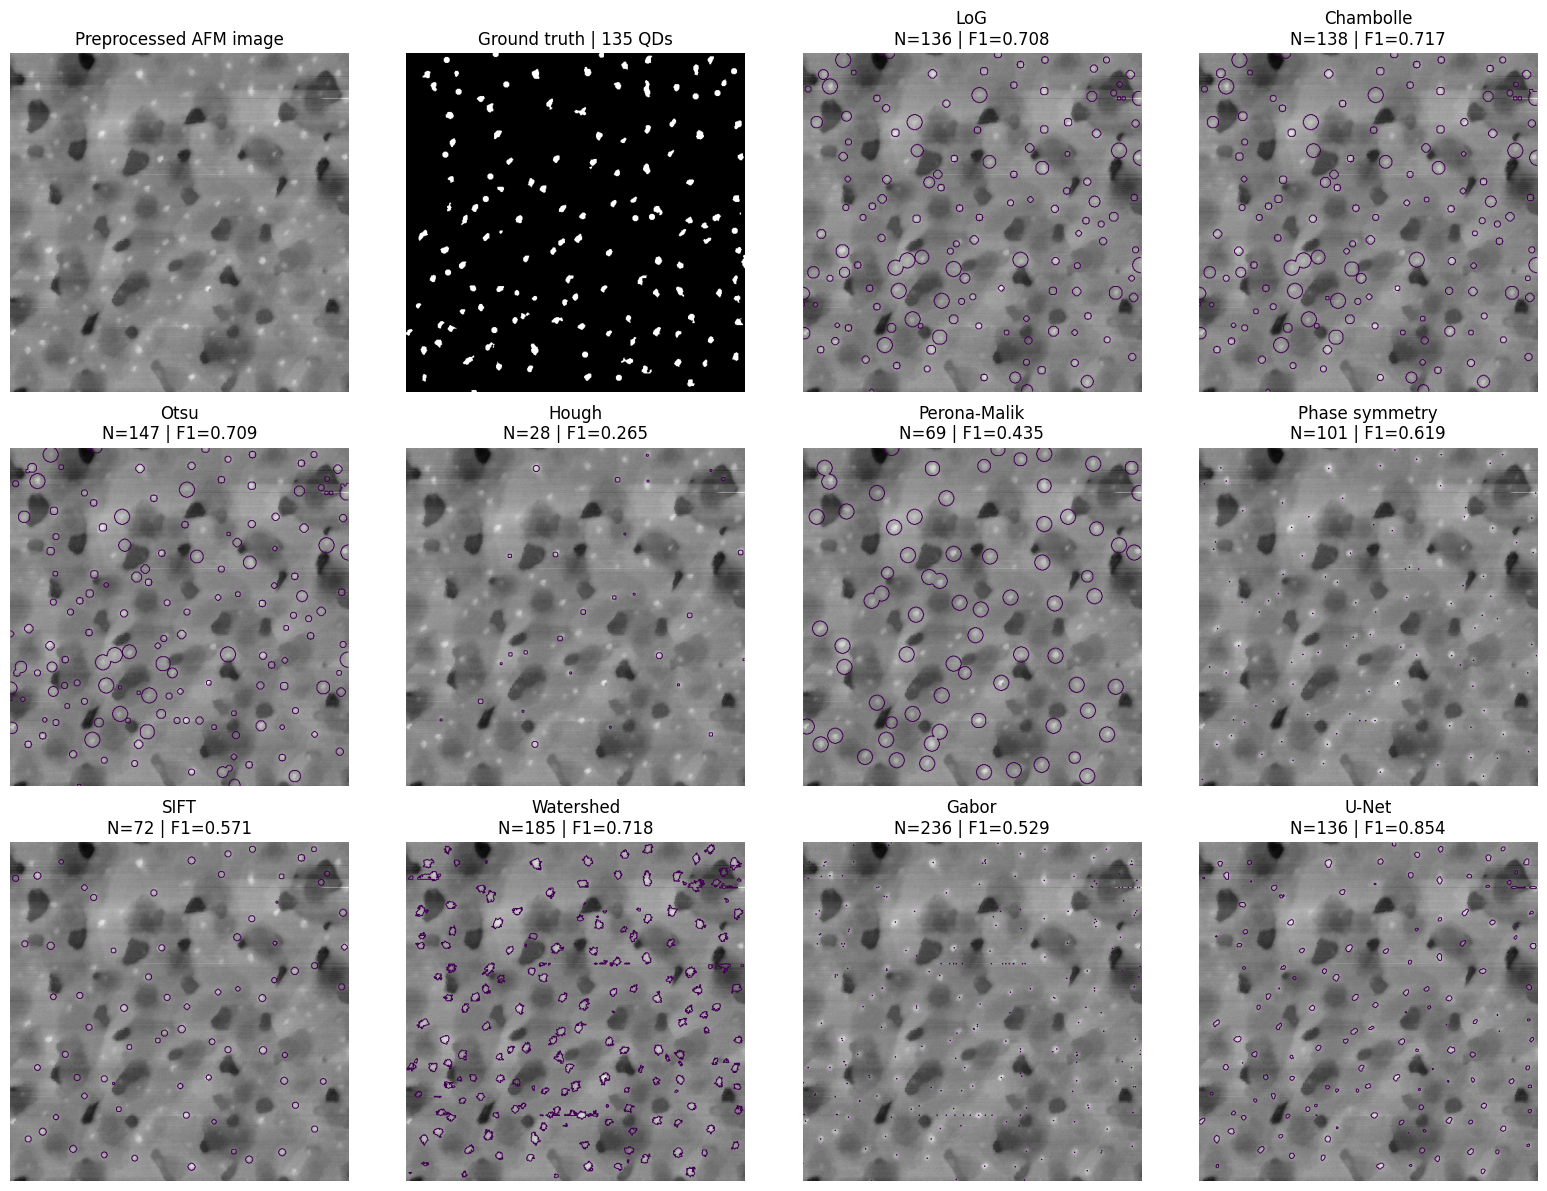

In [44]:
# DISPLAY ALL ALGORITHM MASKS BESIDE THE GROUND TRUTH
display_stage = "after_height_filter"
names = list(algorithm_results.keys())
ncols = 4
nrows = int(np.ceil((len(names) + 2) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = np.asarray(axes).ravel()

axes[0].imshow(X_test, cmap="gray"); axes[0].set_title("Preprocessed AFM image"); axes[0].axis("off")
axes[1].imshow(Y_test, cmap="gray"); axes[1].set_title(f"Ground truth | {ndimage.label(Y_test, structure=np.ones((3,3)))[1]} QDs"); axes[1].axis("off")

for ax, name in zip(axes[2:], names):
    mask = algorithm_results[name][display_stage]["mask"]
    metrics = fe.evaluate_feature_masks(Y_test, mask, tolerance=3.0)
    ax.imshow(X_test, cmap="gray"); ax.contour(mask, levels=[0.5], linewidths=0.7)
    ax.set_title(f"{name}\nN={metrics['Predicted count']} | F1={metrics['F1']:.3f}"); ax.axis("off")

for ax in axes[len(names)+2:]: ax.axis("off")
plt.tight_layout(); plt.show()

### DISPLAY ERROR OVERLAY FOR EVERY ALGORITHM

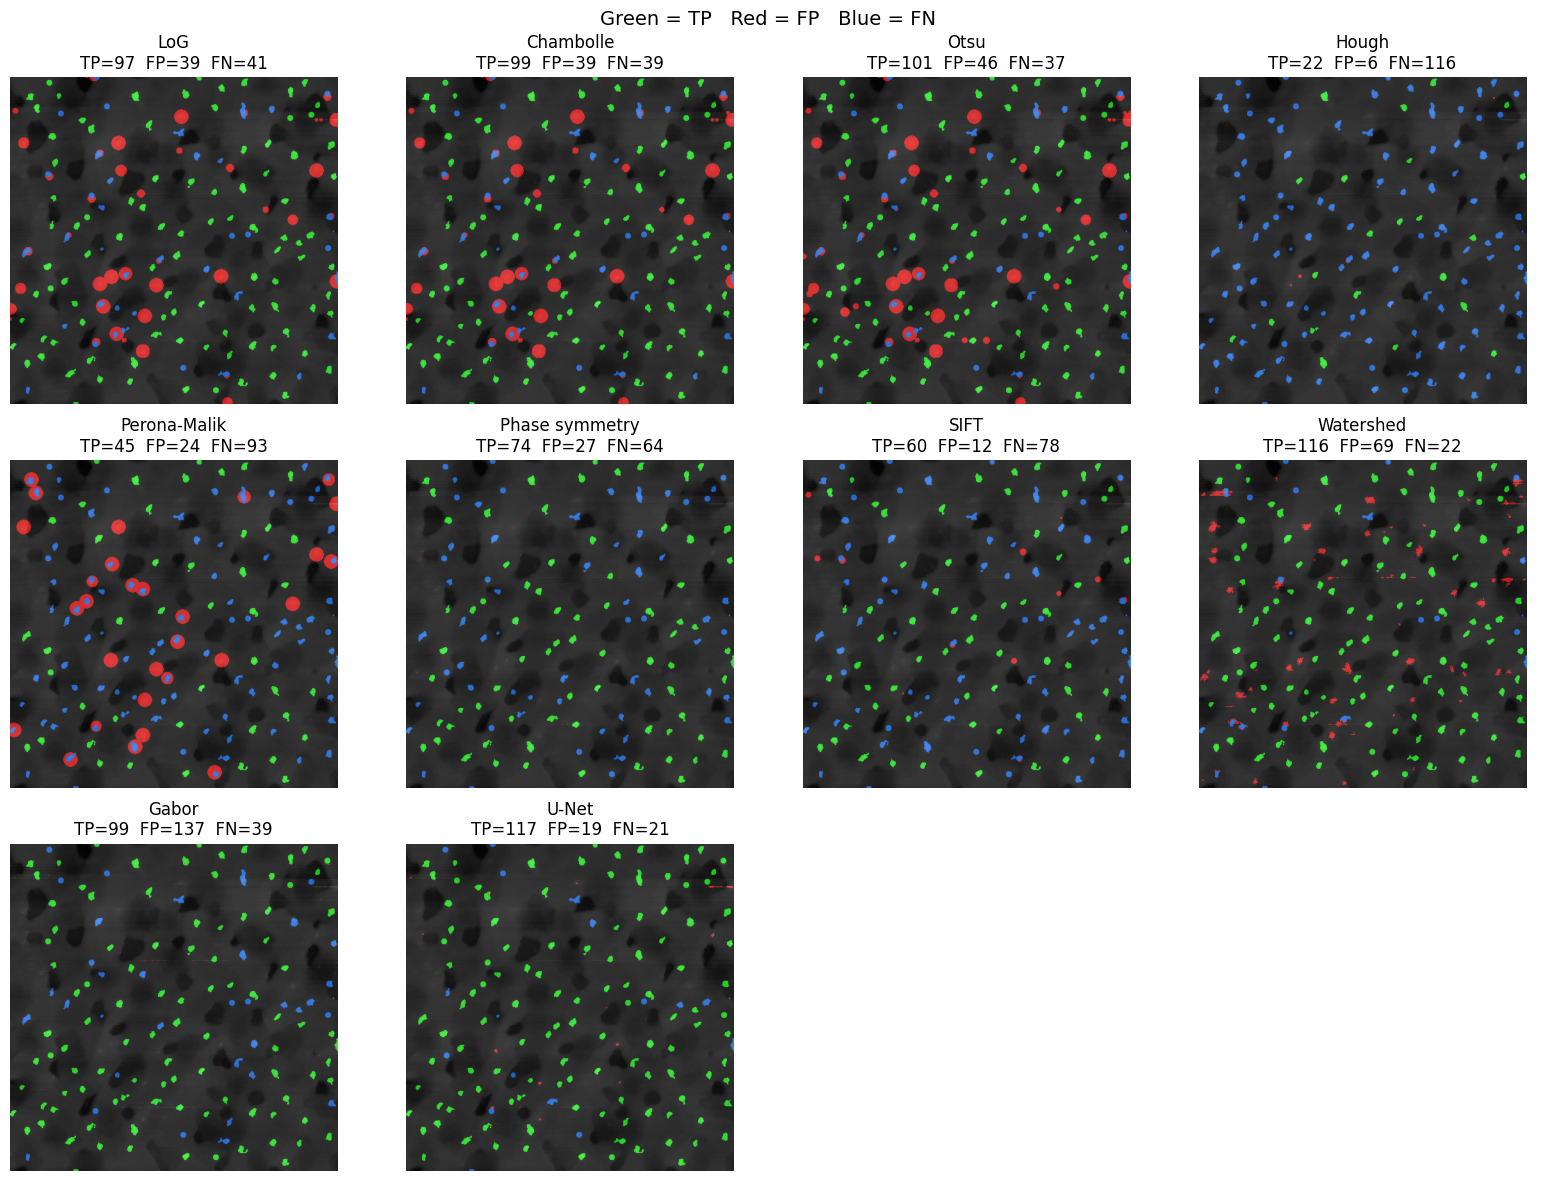

In [45]:
ncols = 4
nrows = int(np.ceil(len(names)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = np.asarray(axes).ravel()

for ax, name in zip(axes, names):
    mask = algorithm_results[name][display_stage]["mask"]
    metrics = fe.evaluate_feature_masks(Y_test, mask, tolerance=3.0)
    ax.imshow(X_test, cmap="gray")
    ax.imshow(fe.make_error_overlay(Y_test, mask), alpha=0.65)
    ax.set_title(f"{name}\nTP={metrics['TP']}  FP={metrics['FP']}  FN={metrics['FN']}"); ax.axis("off")

for ax in axes[len(names):]: ax.axis("off")
fig.suptitle("Green = TP   Red = FP   Blue = FN", fontsize=14)
plt.tight_layout(); plt.show()

### PRECISION / RECALL / F1 BAR GRAPH

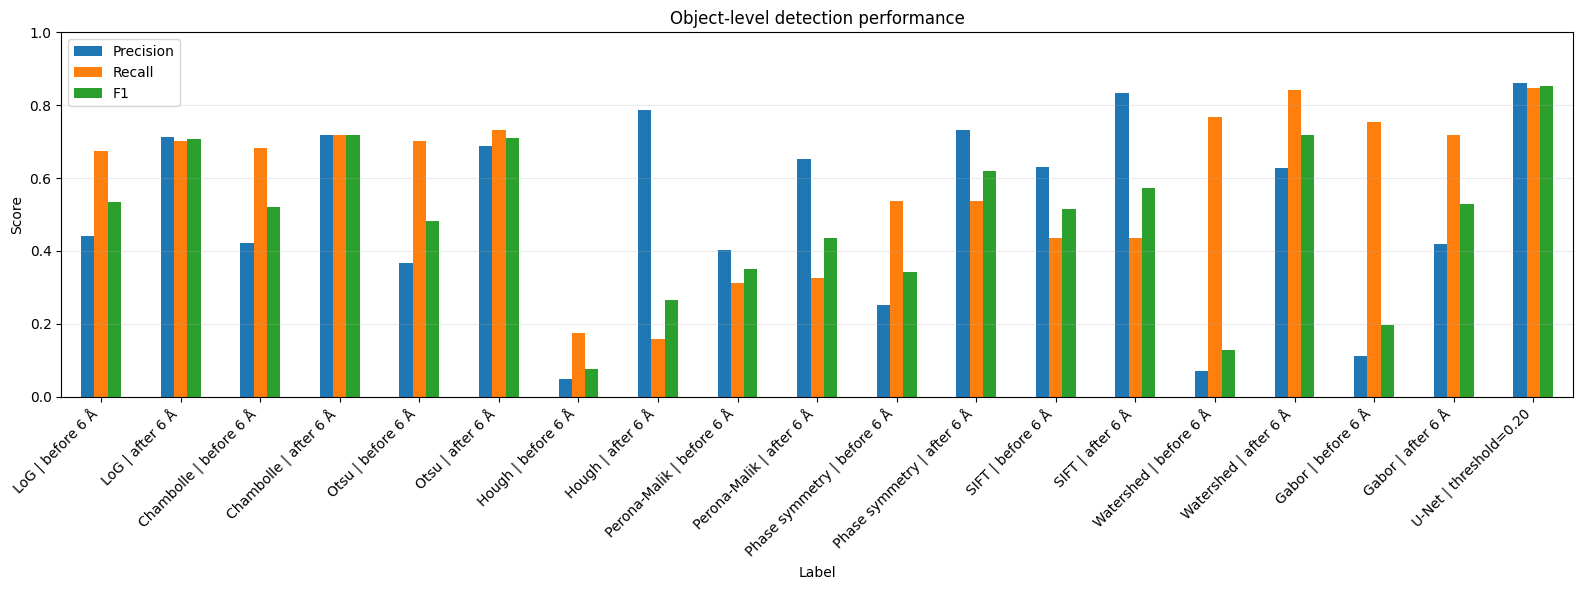

In [46]:
plot_df = results_df.copy()

plot_df["Label"] = plot_df["Algorithm"] + " | " + plot_df["Stage"].replace({"before_height_filter":"before 6 Å", "after_height_filter":"after 6 Å"})
metric_df = plot_df.set_index("Label")[["Precision","Recall","F1"]]

ax = metric_df.plot(kind="bar", figsize=(16,6))
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.set_title("Object-level detection performance")
ax.grid(axis="y", alpha=0.25); plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### TP / FP / FN BAR GRAPH

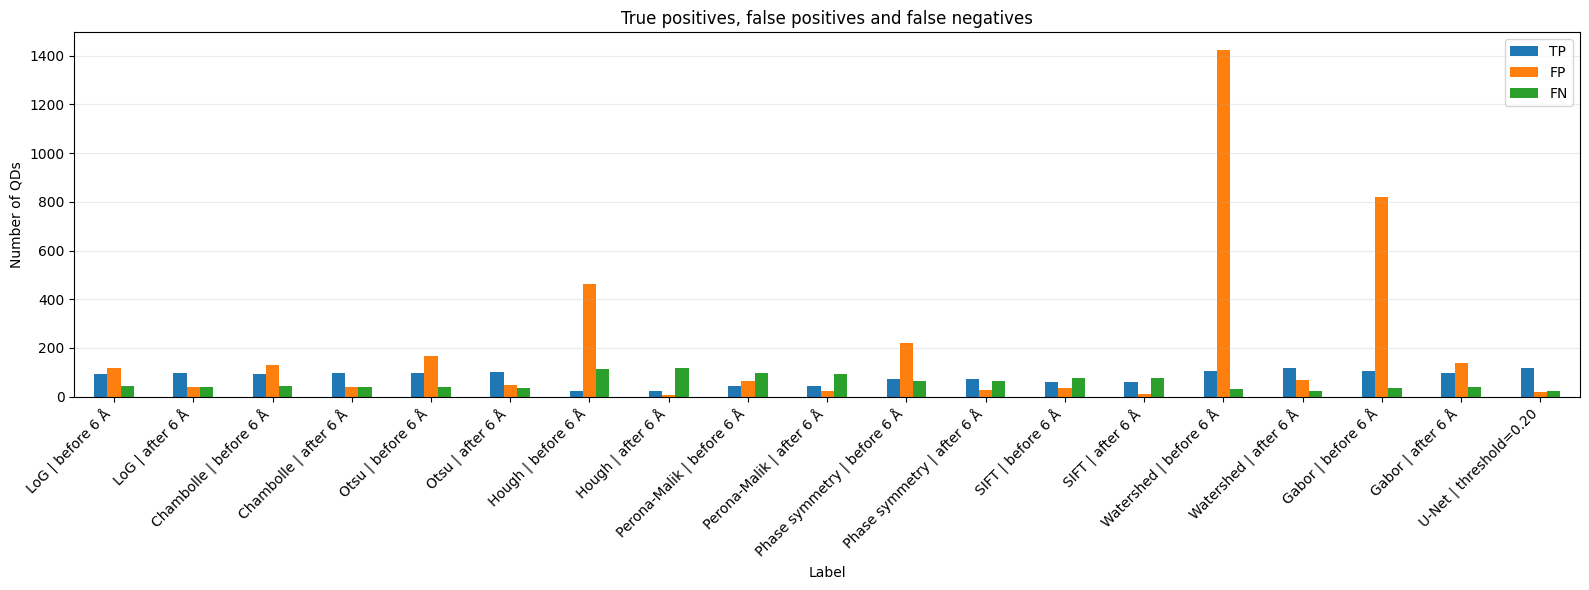

In [47]:
count_df = plot_df.set_index("Label")[["TP","FP","FN"]]
ax = count_df.plot(kind="bar", figsize=(16,6))

ax.set_ylabel("Number of QDs")
ax.set_title("True positives, false positives and false negatives")
ax.grid(axis="y", alpha=0.25) 
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


### ACTUAL PREDICTED COUNT AGAINST GROUND-TRUTH COUNT

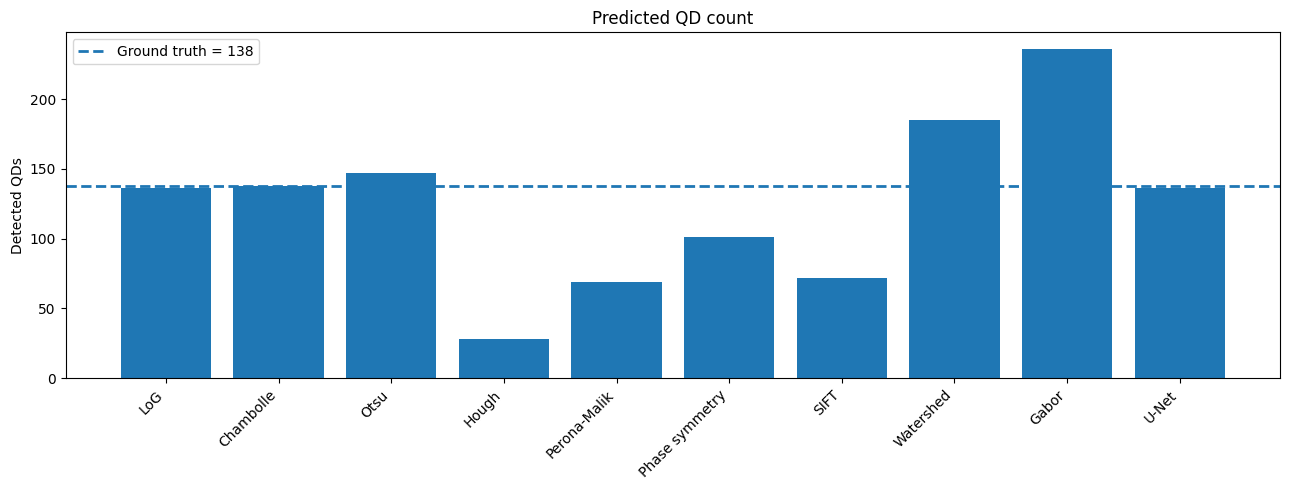

In [48]:
after_df = results_df[(results_df["Stage"] == "after_height_filter") | (results_df["Algorithm"] == "U-Net")].copy()
fig, ax = plt.subplots(figsize=(13,5))
x = np.arange(len(after_df))
ax.bar(x, after_df["Predicted count"])

ax.axhline(after_df["GT count"].iloc[0], 
           linestyle="--", 
           linewidth=2, 
           label=f"Ground truth = {after_df['GT count'].iloc[0]}")

ax.set_xticks(x)
ax.set_xticklabels(after_df["Algorithm"], rotation=45, ha="right")
ax.set_ylabel("Detected QDs")
ax.set_title("Predicted QD count")
ax.legend() 

plt.tight_layout()
plt.show()

### SORTED F1 GRAPH — SIMPLE OVERALL RANKING

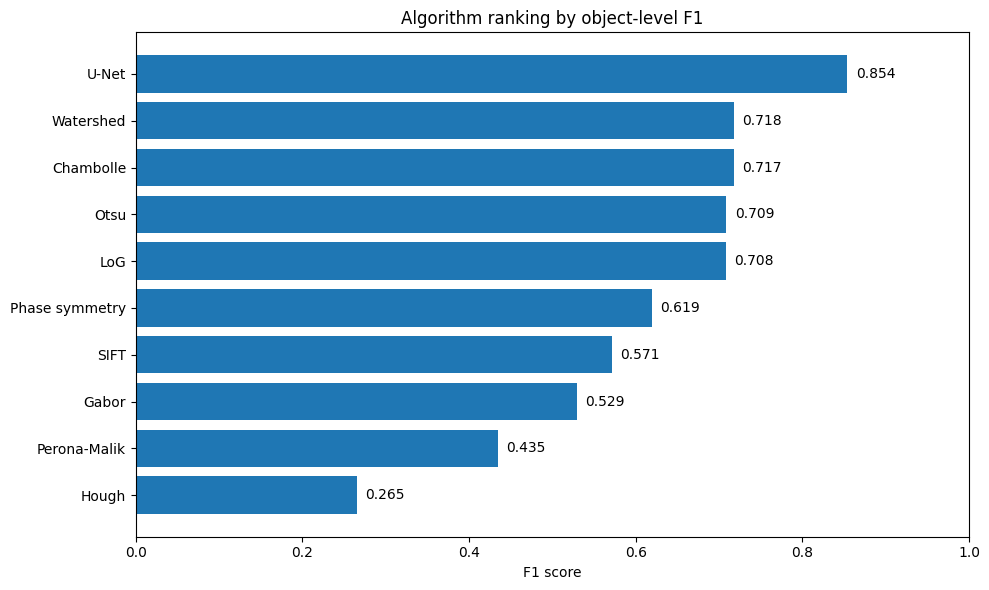

In [49]:
ranking = after_df.sort_values("F1", ascending=True)
fig, ax = plt.subplots(figsize=(10,6))
ax.barh(ranking["Algorithm"], ranking["F1"])

ax.set_xlim(0,1)
ax.set_xlabel("F1 score")
ax.set_title("Algorithm ranking by object-level F1")

for i, value in enumerate(ranking["F1"]): 
    ax.text(value + 0.01, i, f"{value:.3f}", va="center")

plt.tight_layout() 
plt.show()

### U-NET PROBABILITY MAP + FINAL MASK + GROUND TRUTH

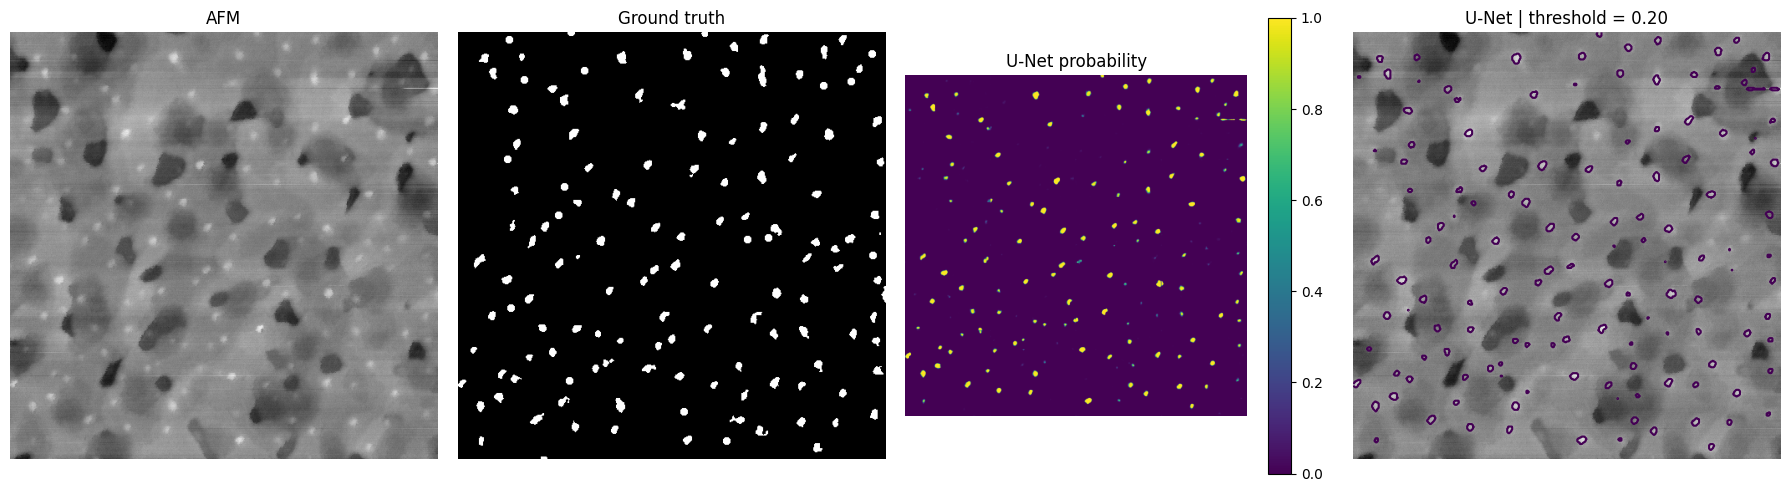

In [50]:
fig, axes = plt.subplots(1,4,figsize=(18,5))

axes[0].imshow(X_test,cmap="gray")
axes[0].set_title("AFM")

axes[1].imshow(Y_test,cmap="gray")
axes[1].set_title("Ground truth")

im = axes[2].imshow(prediction,cmap="viridis",vmin=0,vmax=1)
axes[2].set_title("U-Net probability")
fig.colorbar(im,ax=axes[2])

axes[3].imshow(X_test,cmap="gray")
axes[3].contour(unet_mask,levels=[0.5])
axes[3].set_title("U-Net | threshold = 0.20")

for ax in axes: 
    ax.axis("off")

plt.tight_layout()
plt.show()

### U-NET THRESHOLD: OBJECT PRECISION / RECALL / F1

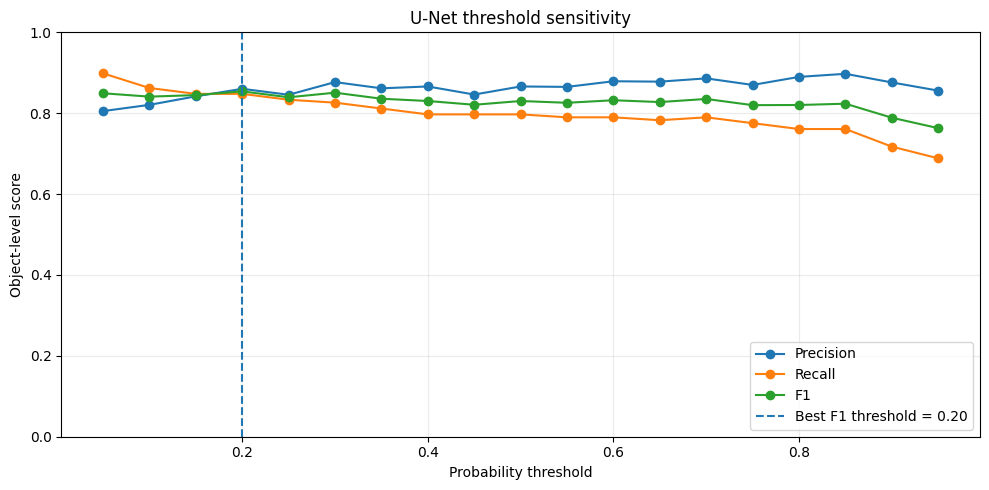

In [51]:
threshold_rows = []

for threshold in np.arange(0.05,0.96,0.05):
    mask = remove_small_objects(prediction >= threshold, min_size=1)
    m = fe.evaluate_feature_masks(Y_test, mask, tolerance=3.0)
    threshold_rows.append({"Threshold":threshold, **m})

unet_threshold_df = pd.DataFrame(threshold_rows)
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(unet_threshold_df["Threshold"],unet_threshold_df["Precision"],marker="o",label="Precision")
ax.plot(unet_threshold_df["Threshold"],unet_threshold_df["Recall"],marker="o",label="Recall")
ax.plot(unet_threshold_df["Threshold"],unet_threshold_df["F1"],marker="o",label="F1")

best = unet_threshold_df.loc[unet_threshold_df["F1"].idxmax()]

ax.axvline(best["Threshold"],linestyle="--",label=f"Best F1 threshold = {best['Threshold']:.2f}")
ax.set_xlabel("Probability threshold")
ax.set_ylabel("Object-level score")
ax.set_ylim(0,1)
ax.set_title("U-Net threshold sensitivity")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


### U-NET THRESHOLD: NUMBER OF DETECTED QDs

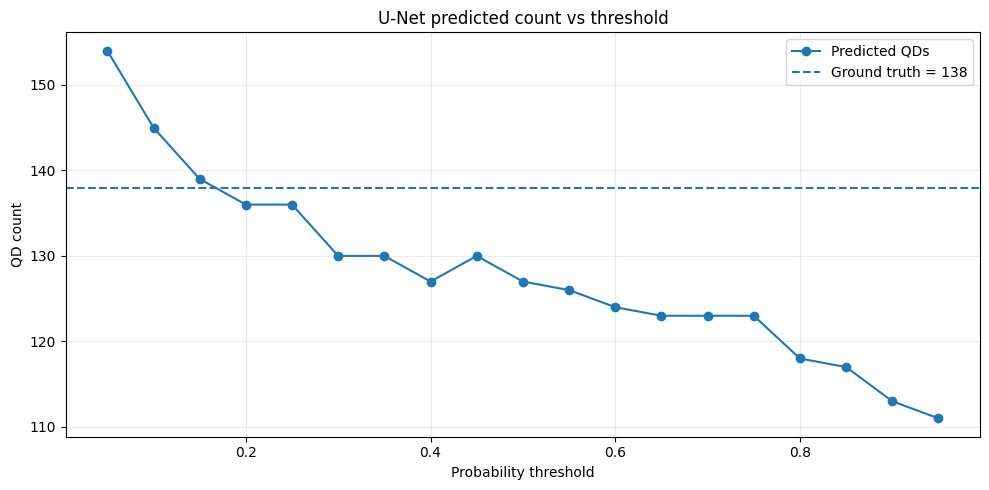

In [52]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(unet_threshold_df["Threshold"],unet_threshold_df["Predicted count"],marker="o",label="Predicted QDs")
ax.axhline(unet_threshold_df["GT count"].iloc[0],linestyle="--",label=f"Ground truth = {unet_threshold_df['GT count'].iloc[0]}")
ax.set_xlabel("Probability threshold")
ax.set_ylabel("QD count")
ax.set_title("U-Net predicted count vs threshold")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### DISPLAY NUMERICAL TABLE TOO

In [53]:
display(results_df.sort_values(["Stage","F1"], ascending=[True,False]).round({"Precision":3,"Recall":3,"F1":3}))

,Algorithm,Stage,GT count,Predicted count,TP,FP,FN,Precision,Recall,F1
15,Watershed,after_height_filter,138,185,116,69,22,0.627,0.841,0.718
3,Chambolle,after_height_filter,138,138,99,39,39,0.717,0.717,0.717
5,Otsu,after_height_filter,138,147,101,46,37,0.687,0.732,0.709
1,LoG,after_height_filter,138,136,97,39,41,0.713,0.703,0.708
11,Phase symmetry,after_height_filter,138,101,74,27,64,0.733,0.536,0.619
13,SIFT,after_height_filter,138,72,60,12,78,0.833,0.435,0.571
17,Gabor,after_height_filter,138,236,99,137,39,0.419,0.717,0.529
9,Perona-Malik,after_height_filter,138,69,45,24,93,0.652,0.326,0.435
7,Hough,after_height_filter,138,28,22,6,116,0.786,0.159,0.265
0,LoG,before_height_filter,138,211,93,118,45,0.441,0.674,0.533


# Data Analysis and Visualisation 

In [1]:
plot_df = results_df.copy()

plot_df["Label"] = plot_df["Algorithm"] + " | " + plot_df["Stage"].replace({"before_height_filter":"before 6 Å", "after_height_filter":"after 6 Å"})
metric_df = plot_df.set_index("Label")[["Precision","Recall","F1"]]

ax = metric_df.plot(kind="bar", figsize=(16,6))
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.set_title("Object-level detection performance")
ax.grid(axis="y", alpha=0.25); plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

NameError: name 'results_df' is not defined